# 언더샘플링 3방식 비교 — k-means · CLARA k-medoids · CSSMC (HI-Large · 트리 9클래스)

손은총 · 자금세탁소 · 2026-09-28 · 상태 **제안·미결**(결정은 팀 다섯 명이 함께 한다)

**이 노트북 하나로 끝난다.** 언더샘플링 3방식을 돌리는 코드 · 학습·채점 코드 · 시각화 코드 · 결론 계산이 모두 들어 있고, 다른 파일을 부르지 않는다. 아래 그림과 결론은 실제로 돌려서 나온 것이다.

1. 각 방식으로 **학습에 남길 정상 행을 고르고** → 2. 그 자료로 **팔마다 모델을 학습·채점하고** → 3. **표와 그림**으로 정리해서 → 4. **"어느 방식이 · 어떤 점에서 · 왜 제일 좋은가"** 를 계산한다.
4의 문장·수치는 전부 3의 표에서 계산한다. 사람이 적어 넣은 값은 없다.

## 지금 이 노트북이 하는 일 (첫 셀의 `ARGV`)

기본값은 `--stage post` — 이미 끝나 있는 09-24 학습 결과 25팔을 읽어 **표·그림·결론만** 다시 만든다(수십 초). 처음부터 학습까지 하려면 `--stage all` 로 바꾼다(약 25시간).

| 묶음 | 단계 | 뜻 | 실측(09-22·23) |
|---|---|---|---|
| `prep` | stats → kmeans → clara → select → subsets → report | 어떤 행을 고르나 | 약 1시간 30분 |
| | raw → train | 팔마다 학습·채점 | 24팔 18시간 + full_w300 5.5시간 |
| `post` | analyze → figs → verdict | 그래서 어느 게 왜 좋은가 | 수십 초 |

끝난 단계는 `<--out>/_stages/<단계>.json` 으로, 끝난 팔은 `arms/<팔>/run.json` 으로 건너뛴다. 다시 돌리려면 그 파일을 지운다.

## 어디서 온 코드인가 (`us_cmp_20260922/code/` 9개 파일 → 이 노트북 하나)

| 셀 | 원본 | 하는 일 |
|---|---|---|
| 설정 | (노트북용) | `RUN` · `ARGV` |
| §0~§2 | `us_lib.py` | 설정값·출처 · 공용 함수 |
| §3 | `us_step2_stats.py` | 공통 통계(표준화·적합 표본·히스토그램 구간) |
| §4 | `us_step3_kmeans.py` | k-means (CSSMC 도 이 군집을 쓴다) |
| §5 | `us_step4_clara.py` | CLARA k-medoids |
| §6 | `us_step5_select.py` | **세 방식이 갈리는 곳** — 선택 + 분포 왜곡 |
| §7 | `us_step7_subsets.py` | 학습 subset |
| §8 | (새로) | 방식 × r 비교표 |
| §9 | `us_restore_nb25_raw.py` | 채점용 val·test 원시 파일 |
| §10 | `us_train.py` | 팔 학습 → val 로 선택 → test 한 번 채점 |
| §11 | `us_analyze.py` | 팔별 산출물 → T11_* 표 |
| §12 | `us_make_notebook.py` | **그림 F1~F8** |
| §13 | (새로) | **결론** — 지표별 1위·이유·한계 + 그림 F9 |
| §14 | | 실행 |

알고리즘·상수·산출 파일 이름은 바꾸지 않았다. §13 말고 새 계산은 없다.

## 원칙

- **무작위 없음**(사용자 결정 Q1 ② 09-22): 적합 표본은 시간순 일정 간격, 군집 안 선택은 중심 근접 순서만, CSSMC 후보는 시작 오프셋, CLARA 표본은 mod 5 갈래 + 일정 간격. 행을 뽑거나 섞는 난수는 어디에도 없다.
- 공통 조건은 노트북 25 와 같다(54열 · 9클래스 · 패턴 밖 세탁 제외 · 태훈님 분할 · LightGBM 설정). **팔마다 다른 것은 "학습 행을 고르는 방식과 가중치"뿐이다.**
- 설정값 출처는 §1 `CFG` 주석에 줄마다 적혀 있다(팀 결정 / 사용자 결정 / 기존 코드 파일:줄 / 논문 / 임의).

## 실행 전 필요

`/tmp/tree9_work/` (결합 파일 85일 + 태훈님 코드 복사본). 비어 있으면 — 컨테이너를 다시 만들면 사라진다:

```bash
B=/workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921
mkdir -p /tmp/tree9_work
cp -a /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921 /tmp/tree9_work/code
cp "$B/meta/pos_attempt.npz" "$B/meta/joined_stats.json" /tmp/tree9_work/
cp -a "$B/joined" /tmp/tree9_work/
```

## 주의

- 09-28 02:45 에 `aml_feature_schema.csv` 가 36개 판(엣지 `amt_z_pay_ccy` 추가)으로 바뀌었다. 그 열은 결합 파일 62열에 없어 자동으로 빠지고 로그에 남는다(09-22 실험과 같은 54열인지 `assert` 로 확인). 09-22 판을 쓰려면 `--schema` 로 지정한다.
- `--smoke` 는 `joined_small` 이 있어야 한다(09-21 저장본에는 없다).
- 긴 작업은 노트북보다 터미널이 안전하다. 그때만 이 노트북을 `.py` 로 내보내 `setsid nohup python3 -u <파일>.py --stage all &` 로 돌린다(`--isolate` 가 켜져 단계·팔마다 프로세스가 새로 떠 메모리를 돌려준다).


In [1]:
RUN = True         # False 로 두면 정의만 하고 아무 작업도 돌지 않는다
ARGV = ['--stage', 'post', '--no-isolate',
        '--source', '/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922',
        '--out',    '/workspace/Final_preprocess/HI-Large_EDA/us_merged_20260928/_from_20260924']
# 자주 쓰는 ARGV:
#  ['--stage','post','--source','<학습이 끝난 폴더>']            표·그림·결론만 (수십 초)  ← 지금 기본값
#  ['--stage','prep']                                          고르기만 (약 1시간 30분)
#  ['--stage','all']                                           처음부터 끝까지 (약 25시간)
#  ['--stage','train','--arms','cssmc_r300_w300']              팔 하나만 학습
#  ['--stage','all','--methods','km,cssmc','--ratios','10,300'] 방식·r 줄이기
#  ['--stage','all','--dry-run']                               계획·예상 시간만

In [2]:
#!/usr/bin/env python3
"""us_undersample_compare.py — 언더샘플링 3방식을 한 파일에서 끝까지 비교한다 (k-means · CLARA k-medoids · CSSMC).

손은총 · 자금세탁소 · 2026-09-28 · HI-Large · 상태 제안·미결(결정은 팀 다섯 명이 함께 한다)

이 파일 하나가 하는 일
  [1] 각 방식으로 학습에 남길 정상 행을 고르고  [2] 그 자료로 팔마다 모델을 학습·채점하고
  [3] 표와 그림으로 정리해서  [4] "어느 방식이 · 어떤 점에서 · 왜 제일 좋은가"를 계산해 내놓는다.
  [4]의 문장·수치는 전부 [3]의 표에서 계산한다(사람이 적어 넣은 값 없음).

무엇을 합친 것인가 (us_cmp_20260922/code/ 의 9개 파일 → 1개)
  us_lib.py            → §1 설정 · §2 공용 함수
  us_step2_stats.py    → stage_stats()    2단계 공통 통계
  us_step3_kmeans.py   → stage_kmeans()   3단계 k-means (CSSMC 도 이 군집을 쓴다)
  us_step4_clara.py    → stage_clara()    4단계 CLARA k-medoids
  us_step5_select.py   → stage_select()   5단계 방식별 선택 + 분포 왜곡  ★ 세 방식이 갈리는 곳
  us_step7_subsets.py  → stage_subsets()  7단계 학습 subset
  us_restore_nb25_raw.py → stage_raw()    채점용 val·test 원시 파일 복원
  us_train.py          → stage_train()    팔 학습 → val 로 선택 → test 한 번 채점
  us_analyze.py        → stage_analyze()  팔별 산출물 → T11_* 표
  us_make_notebook.py  → stage_figs()     그림 F1~F8
  (새로 붙임)          → stage_report()   방식 × r 비교표 D0 · stage_verdict() 결론 + 그림 F9
  알고리즘·상수·산출 파일 이름은 바꾸지 않았다. verdict 외에 새 계산은 없다.

단계
  stats → kmeans → clara → select → subsets → report   (= --stage prep, "어떤 행을 고르나")
  raw → train                                          (학습. 제일 오래 걸린다)
  analyze → figs → verdict                             (= --stage post, "그래서 어느 게 왜 좋은가")

원칙 (합치기 전과 같다)
  - 무작위 없음(사용자 결정 Q1 [2] 09-22): 적합 표본은 시간순 일정 간격, 군집 안 선택은 중심 근접 순서만,
    CSSMC 후보는 시작 오프셋, CLARA 표본은 mod 5 갈래 + 일정 간격. 행을 뽑거나 섞는 난수는 어디에도 없다.
  - 공통 조건은 노트북 25 와 같다(54열 · 9클래스 · 패턴 밖 세탁 제외 · 태훈님 분할 · LightGBM 설정).
    팔마다 다른 것은 "학습 행을 고르는 방식과 가중치"뿐이다.
  - 큰 중간 파일은 /tmp/us_merged/(컨테이너 재생성 시 사라짐, 다시 만들 수 있음), 작은 결과는 --out 폴더.
  - 기존 결과 폴더(us_cmp_20260922 · fix_20260927)에는 쓰지 않는다. --out 기본값은 이 파일이 있는 새 폴더다.

쓰는 법
  # 이미 학습된 팔로 결론만 (수 초) — 09-24 실험 결과를 그대로 쓴다
  python3 us_undersample_compare.py --stage post --source /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922
  # 고르기만 (몇 시간)
  python3 us_undersample_compare.py --stage prep
  # 처음부터 끝까지 (약 20~28시간)
  python3 us_undersample_compare.py --stage all
  # 방식·팔 줄이기
  python3 us_undersample_compare.py --stage all --methods km,cssmc --ratios 10,300
  python3 us_undersample_compare.py --stage train --arms cssmc_r300_w300
  # 계획·예상 시간만
  python3 us_undersample_compare.py --stage all --dry-run
  백그라운드: setsid nohup python3 -u us_undersample_compare.py --stage all > 로그.log 2>&1 < /dev/null &
  확인: ps -eo pid,etime,args | grep "[u]s_undersample"   (pgrep -f 금지 — 09-22 사고)

실행 전 필요
  /tmp/tree9_work/ (결합 파일 85일 + 태훈님 코드 복사본). 비어 있으면:
    B=/workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921
    mkdir -p /tmp/tree9_work && cp -a /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921 /tmp/tree9_work/code
    cp "$B/meta/pos_attempt.npz" "$B/meta/joined_stats.json" /tmp/tree9_work/ && cp -a "$B/joined" /tmp/tree9_work/
  (--stage post 는 /tmp 없이도 돈다 — 표만 읽는다. 단 tree9_lib import 때문에 code 복사본은 필요하다.)

주의
  - --isolate(기본 켜짐)일 때만 단계마다(학습은 팔마다) 프로세스가 새로 뜬다. --no-isolate 는 메모리가 더 든다.
  - 끝난 단계는 --out/_stages/<단계>.json 이 있으면 건너뛴다. 학습은 팔별 run.json 으로 건너뛴다.
  - --smoke 는 joined_small 이 있어야 한다(09-21 저장본에는 없다).
"""
import os

_T = os.environ.get('AML_THREADS', '3')
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, _T)                      # numpy 보다 먼저 — OpenBLAS 빌드 한도 64 < 호스트 80코어(스모크 segfault)

import sys, gc, json, time, signal, hashlib, argparse, subprocess
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
import tree9_lib as L                                  # sys.path 에 .pylibs 를 넣어 주므로 lightgbm 은 이 뒤에 import

try:
    SELF = Path(__file__).resolve()
except NameError:                                      # .ipynb 보관본에는 __file__ 이 없다
    SELF = Path('/workspace/Final_preprocess/HI-Large_EDA/us_merged_20260928/us_undersample_compare.py').resolve()
_NB = 'ARGV' in globals()                              # .ipynb 로 돌고 있는가(첫 셀이 RUN·ARGV 를 정한다)
STAGES = ('stats', 'kmeans', 'clara', 'select', 'subsets', 'report',      # 앞: 어떤 행을 고르나(연쇄 A)
          'raw', 'train', 'analyze', 'figs', 'verdict')                   # 뒤: 그래서 어느 게 왜 좋은가(연쇄 B·C + 분석)
GROUP = dict(all=STAGES, prep=STAGES[:6], post=('analyze', 'figs', 'verdict'))

In [3]:
# ══════════════════════════════════════════════════════════════════════
# §0 명령줄
# ══════════════════════════════════════════════════════════════════════
_ap = argparse.ArgumentParser(description='언더샘플링 3방식 비교 (한 파일)', formatter_class=argparse.RawDescriptionHelpFormatter)
_ap.add_argument('--stage', default='all', choices=tuple(GROUP) + STAGES,
                 help='all(전부) · prep(고르기만) · post(이미 있는 팔로 분석·그림·결론) · 또는 단계 하나')
_ap.add_argument('--out', default=str(SELF.parent), help='결과·인덱스를 쓸 폴더 (기본: 이 파일이 있는 폴더)')
_ap.add_argument('--big', default='', help='큰 중간 파일 폴더 (기본 /tmp/us_merged/full, 스모크는 /tmp/us_merged/smoke)')
_ap.add_argument('--methods', default='km,clara,cssmc', help='쉼표로. km,clara,cssmc 중 (기본 전부)')
_ap.add_argument('--ratios', default='', help='쉼표로. 남길 정상 = r × 학습 패턴 세탁. 비우면 기본 격자(10,30,100,300 · 스모크 2,5)')
_ap.add_argument('--smoke', action='store_true', help='작은 기간(joined_small)으로 전 단계 1회 — 수치 의미 없음')
_ap.add_argument('--isolate', dest='isolate', action='store_true', default=not _NB,
                 help='단계·팔마다 별도 프로세스로(.py 로 실행할 때 기본). 앞 단계 메모리를 완전히 반납한다')
_ap.add_argument('--no-isolate', dest='isolate', action='store_false',
                 help='한 프로세스에서 전부 — 메모리가 더 든다. 노트북(.ipynb)은 이쪽이 기본이라 .py 파일이 없어도 된다')
_ap.add_argument('--schema', default='/workspace/Final_preprocess/aml_feature_schema.csv',
                 help='피처 스키마 csv. 09-22 실험판(노드 19 + 엣지 16)은 '
                      '/workspace/Final_preprocess/.ipynb_checkpoints/aml_feature_schema-checkpoint.csv')
_ap.add_argument('--anon-stop', type=float, default=19.0, help='AnonGuard 한도 GiB (기본 19.0 = mem_guard STOP 70%%)')
_ap.add_argument('--source', default='', help='post 단계가 팔·분포왜곡표를 읽어올 실험 폴더. 비우면 --out. '
                 '예전 09-24 결과를 쓰려면 /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922')
_ap.add_argument('--arms', default='', help='train 단계에서 돌릴 팔(쉼표). 비우면 전부. 예: cssmc_r300_w300')
_ap.add_argument('--resume', action='store_true', help='train: 체크포인트에서 이어 학습')
_ap.add_argument('--dry-run', action='store_true', help='무엇을 할지만 찍고 끝낸다')
A = _ap.parse_args(globals().get('ARGV'))          # 노트북 보관본은 첫 셀의 ARGV, 스크립트는 sys.argv

SMOKE = A.smoke or os.environ.get('US_SMOKE') == '1'
METHODS = tuple(m.strip() for m in A.methods.split(',') if m.strip())
assert set(METHODS) <= {'km', 'clara', 'cssmc'} and METHODS, f'--methods 가 이상하다: {A.methods}'

In [4]:
# ══════════════════════════════════════════════════════════════════════
# §1 설정값과 출처 — us_lib.py CFG 그대로 (run.json · *_meta.json 에 그대로 적는다)
# ══════════════════════════════════════════════════════════════════════
CFG = dict(
    fit_step=(5 if SMOKE else 91),               # 적합 표본 = train 정상 행을 시간순 매 fit_step 번째. 임의 — 예전 fit_subsample 100만(prep9/undersample.py:31)과 같은 크기가 되게 91,327,582/91 ≈ 1,003,600
    k_grid=((4, 8) if SMOKE else (64, 256, 1024)),      # 기존 코드 값 make_cluster_indices.py:53 (팀 결정 아님)
    k_rule_tol=1.10,                             # "최적 inertia/row 대비 10% 이내 최소 K" make_cluster_indices.py:74
    kmeans_max_iter=100, kmeans_tol=1e-4,        # max_iter 100 = prep9/undersample.py:41 · tol = sklearn 기본값. 전배치 KMeans(lloyd, n_init 1): MiniBatch 대신(무작위 없음)
    nbin=32, laplace=0.5, n_cand=(3 if SMOKE else 20),  # CSSMC KL 계산·후보 수 — 논문에 없어 make_cluster_indices.py 에서 임의로 정했던 값 그대로
    ratios=((2, 5) if SMOKE else (10, 30, 100, 300)),   # 사용자 결정 Q4(09-22)
    clara_samples=5, clara_extra=40,             # CLARA 표본 5회 × (40+2K)행 — Kaufman & Rousseeuw(1990) 기본값
    center_frac=1.0,                             # 군집 안 = 중심 근접 순서만(Q1 [2]). 예전 값 0.5 는 나머지 절반이 무작위였다
    chunk=100_000,                               # 거리 계산 조각 크기(값에 영향 없음)
    pos_weight=300.0,                            # w300 팔: 패턴 300 · 정상 1 — 사용자 결정 (가) 09-21, 태훈님 GNN_REPORT 211·216줄(튜닝 안 한 값)
    max_rounds=(6 if SMOKE else 300),            # 태훈님 GNN_REPORT 216줄
    check_every=(2 if SMOKE else 10), patience_checks=2,   # 10 round 마다 val macro-AP, 2회 연속 안 오르면 멈춤 — 시간 때문에 정한 임의값
    n_ref=200_000,                               # 구간 경계용 행(학습 행을 같은 간격으로 건너뜀) = LightGBM bin_construct_sample_cnt 기본값, 노트북 25 방식
)
if A.ratios:
    CFG['ratios'] = tuple(int(x) for x in A.ratios.split(',') if x.strip())

# 학습 설정 — 노트북 25 = 태훈님 GNN_REPORT 216줄 (팔마다 같다. 다른 것은 학습 행 선택과 가중치뿐)
LGB_P = dict(objective='multiclass', num_class=9, learning_rate=0.1, num_leaves=31, max_depth=6, max_bin=63, num_threads=2, seed=42,
             deterministic=True, force_col_wise=True, bagging_fraction=1.0, bagging_freq=0, feature_fraction=1.0, verbosity=-1)
DS_P = dict(LGB_P, bin_construct_sample_cnt=CFG['n_ref'])
# 팔 이름 = {방식}_r{r}_{w1|w300} + full_w300(언더샘플링 없음, 가중치만) — 비교의 단위
ARM_LIST = [f'{m}_r{r}_{w}' for m in METHODS for r in CFG['ratios'] for w in ('w1', 'w300')] + ['full_w300']
ARM_RUN = [a for a in (x.strip() for x in A.arms.split(',')) if a] or ARM_LIST
for _a in ARM_RUN:
    assert _a in ARM_LIST, f'모르는 팔 {_a} — 가능한 팔: {ARM_LIST}'

# ── 경로 ──
ROOT = Path(A.out).resolve() / ('_smoke' if SMOKE else '')
COMMON, IDXD, RES, STAGED = ROOT / 'common', ROOT / 'indices', ROOT / 'results', ROOT / '_stages'
ARMS, FIGS = ROOT / 'arms', ROOT / '_figs'
BIG = Path(A.big).resolve() if A.big else Path('/tmp/us_merged') / ('smoke' if SMOKE else 'full')
SUBS = BIG / 'subsets'
for _d in (COMMON, IDXD, RES, STAGED, ARMS, FIGS, BIG, SUBS):
    _d.mkdir(parents=True, exist_ok=True)
# post 단계(analyze·figs·verdict)가 읽을 곳 — 새로 학습했으면 ROOT, 예전 결과를 쓰면 --source
SRC = Path(A.source).resolve() if A.source else ROOT
SRC_ARMS, SRC_RES = SRC / 'arms', SRC / 'results'
RAW25 = L.WORK / ('nb25_9c_smoke' if SMOKE else 'nb25_9c')     # 노트북 25 가 만든 val·test 원시 파일 + 전체 학습 bin
FONT = '/workspace/Final_preprocess/HI-Large_EDA/notebooks/_assets/NanumGothic-Regular.ttf'
JD = L.WORK / ('joined_small' if SMOKE else 'joined')          # 62열 결합 파일(태훈님 코드, 09-21)
DAYS = ({'train': ['2022-08-08'], 'val': ['2022-08-09'], 'test': ['2022-08-09']} if SMOKE
        else {s: L.days_of(s) for s in ('train', 'val', 'test')})
K9 = 9
CLASS9 = L.CLASS_NAMES[:8] + ['정상']

# ── 54열(노트북 25 와 같은 선택) ──
# 주의(09-28 확인): /workspace/Final_preprocess/aml_feature_schema.csv 가 09-28 02:45 에 36개 판
#   (노드 19 + 엣지 17, amt_z_pay_ccy 추가 — GitHub docs 브랜치 FEATURE_SPEC_36_피처추가.md)으로 바뀌었다.
#   09-21 결합 파일(62열)에는 그 열이 없어 그대로 읽으면 55열이 되고 L.F62.index 에서 죽는다.
#   (기존 us_cmp_20260922/code/us_lib.py · fix_20260927/code/fix_lib.py 도 지금 import 만 해도 같은 오류로 죽는다.)
#   여기서는 "결합 파일에 실제로 있는 열"만 남기고 뺀 열을 로그·meta 에 적는다 → 09-22 실험과 같은 54열인지 assert 로 확인.
#   09-22 당시 35개 판 사본: /workspace/Final_preprocess/.ipynb_checkpoints/aml_feature_schema-checkpoint.csv (--schema 로 지정)
SCHEMA = Path(A.schema)
SCH = pd.read_csv(SCHEMA, encoding='utf-8-sig')
_node = [L.NAME_FIX.get(f, f) for f in SCH.query("tensor=='node'").sort_values('col_index')['feature']]
_edge = list(SCH.query("tensor=='edge'").sort_values('col_index')['feature'])
NODE19 = [f for f in _node if ('src_' + f) in L.F62]
EDGE16 = [f for f in _edge if f in L.F62]
DROPPED = [f for f in _node if f not in NODE19] + [f for f in _edge if f not in EDGE16]
F54 = ['src_' + f for f in NODE19] + ['dst_' + f for f in NODE19] + EDGE16
IDX = np.array([L.F62.index(f) for f in F54])
assert len(NODE19) == 19 and len(EDGE16) == 16 and len(F54) == 54, (
    f'54열이 안 된다: 노드 {len(NODE19)} · 엣지 {len(EDGE16)} · 스키마 {SCHEMA} · 결합 파일(62열)에 없어 뺀 열 {DROPPED}')

In [5]:
# ══════════════════════════════════════════════════════════════════════
# §2 공용 함수 — us_lib.py 그대로
# ══════════════════════════════════════════════════════════════════════
def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)


def status(text):
    """STATUS.txt = 지금 단계 한 줄(덮어씀) · STATUS_log.txt = 누적."""
    line = f"{text} {time.strftime('%F %T')}"
    (ROOT / 'STATUS.txt').write_text(line + '\n')
    with open(ROOT / 'STATUS_log.txt', 'a') as f:
        f.write(line + '\n')


def sha1(p):
    return hashlib.sha1(Path(p).read_bytes()).hexdigest()[:12]


def code_sha():
    return {SELF.name: (sha1(SELF) if SELF.exists() else '(.ipynb 단독 실행 — .py 없음)')}


def jdump(obj, path):
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=1, default=float))


def top_ps(n=5):
    try:
        return subprocess.run(['ps', '-eo', 'pid,rss,etime,args', '--sort=-rss'], capture_output=True, text=True, timeout=5).stdout.splitlines()[1:n + 1]
    except Exception as e:                       # noqa: BLE001
        return [str(e)]


def install_sigterm(on_term=lambda: None):
    """SIGTERM 을 받으면 시각·anon·ps 상위 5개를 남기고 on_term() 뒤 143 으로 끝낸다(09-22 원인 불명 SIGTERM 대비)."""
    def h(sig, frame):
        log(f'SIGTERM 받음 · anon {L.anon_gib():.2f} GiB · ps 상위: ' + ' | '.join(x.strip()[:110] for x in top_ps()))
        try:
            on_term()
        finally:
            os._exit(143)
    signal.signal(signal.SIGTERM, h)


def to_y9(y9, ip, w):
    """노트북 25 와 같음: 0~7 패턴 그대로, 정상 → 8, 패턴 밖 세탁 → −1(뺄 행). 결합 파일 가중치(세탁 300 · 정상 1)도 확인."""
    assert not ((y9 < 8) & (ip != 1)).any(), '패턴 라벨인데 is_pos=0 인 행이 있다'
    assert np.array_equal(w, np.where(ip == 1, 300.0, 1.0).astype(np.float32)), '가중치가 세탁 300 · 정상 1 이 아니다'
    return np.where(y9 < 8, y9, np.where(ip == 1, -1, 8)).astype(np.int8)


def read54(d):
    """하루 → (패턴 밖 세탁을 뺀 X 54열, y(0~8), edge_id, 뺀 패턴 밖 행 수). 행 순서 = 파일 순서(edge_id 순)."""
    X, y9, ip, w, eid = L.read_day(JD, d)
    y = to_y9(y9, ip, w); k = y >= 0
    Xk = np.ascontiguousarray(X[k][:, IDX]); del X
    return Xk, y[k], eid[k], int((~k).sum())


def train_days_iter():
    for d in DAYS['train']:
        X, y, eid, n_out = read54(d)
        yield d, X, y, eid, n_out


def standardize(X, mean, std):
    return ((X - mean) / (std + 1e-6)).astype(np.float32, copy=False)      # prep9/undersample.py:27 과 같은 식


def assign(Z, C, chunk=None):
    """가장 가까운 중심(argmin 은 |c|²−2z·c 로 BLAS 계산) + 그 중심까지의 정확한 유클리드 거리(다시 계산). 무작위 없음."""
    chunk = chunk or CFG['chunk']
    C = np.ascontiguousarray(C, np.float32); c2 = (C * C).sum(1)
    lab = np.empty(len(Z), np.int32); dist = np.empty(len(Z), np.float32)
    for a in range(0, len(Z), chunk):
        z = Z[a:a + chunk]; l = (c2[None, :] - 2.0 * (z @ C.T)).argmin(1)
        lab[a:a + chunk] = l; dist[a:a + chunk] = np.sqrt(((z - C[l]) ** 2).sum(1))
    return lab, dist


def save_ragged(path, arrs):
    """길이가 다른 1차원 배열 목록 → npz(concat + 경계)."""
    lens = np.array([len(a) for a in arrs], np.int64)
    np.savez(path, data=np.concatenate([np.asarray(a) for a in arrs]) if len(arrs) else np.zeros(0), offs=np.concatenate([[0], np.cumsum(lens)]))


def load_ragged(path):
    z = np.load(path); o = z['offs']
    return [z['data'][o[i]:o[i + 1]] for i in range(len(o) - 1)]


def members(lab, k):
    """군집별 구성원(행 순서 = 시간순 유지). (order, offs): order[offs[c]:offs[c+1]] 이 군집 c."""
    order = np.argsort(lab, kind='stable'); offs = np.searchsorted(lab[order], np.arange(k + 1))
    return order, offs


def quota_for(sizes, n_t):
    """군집 크기 비례 몫, 남는 몫은 큰 군집부터 1개씩(make_cluster_indices.py:108-112 · prep9/undersample.py:70-74)."""
    N = int(sizes.sum()); q = np.floor(sizes * (n_t / N)).astype(np.int64); short = n_t - int(q.sum())
    if short > 0:
        for c in np.argsort(-sizes, kind='stable')[:short]:
            q[c] += 1
    return np.minimum(q, sizes)


def pick_center(quota, dist, order, offs):
    """km·clara: 군집마다 중심(medoid)에 가까운 순서로 몫만큼(center_frac=1.0). 동점은 행 순서."""
    out = []
    for c in range(len(quota)):
        q = int(quota[c])
        if q == 0:
            continue
        mem = order[offs[c]:offs[c + 1]]
        out.append(mem[np.argsort(dist[mem], kind='stable')[:q]])
    return np.sort(np.concatenate(out)) if out else np.zeros(0, np.int64)


def pick_interval(quota, order, offs, j, n_cand):
    """CSSMC 후보 j: 군집 안 시간순 일정 간격(스텝 = 크기/몫), 시작 오프셋 j/n_cand 스텝. 무작위 층화 추출(논문 (2))의 결정적 대체."""
    out = []
    for c in range(len(quota)):
        q = int(quota[c])
        if q == 0:
            continue
        mem = order[offs[c]:offs[c + 1]]; s = len(mem)
        pos = np.floor((np.arange(q) + j / n_cand) * (s / q)).astype(np.int64)
        out.append(mem[np.minimum(pos, s - 1)])
    return np.sort(np.concatenate(out)) if out else np.zeros(0, np.int64)


def macro_ap_k(S, y, chunk=4_000_000):
    """노트북 25 macro_ap_k 와 같음: log softmax(뺄셈 float64 → float32) 점수로 클래스별 AP(L.ap_binary) 평균."""
    n = len(S); lse = np.empty(n, np.float64)
    for a in range(0, n, chunk):
        b = np.asarray(S[a:a + chunk], dtype=np.float64); mx = b.max(axis=1)
        lse[a:a + chunk] = mx + np.log(np.exp(b - mx[:, None]).sum(axis=1)); del b, mx
    aps = []
    for k in range(K9):
        sk = np.empty(n, np.float32)
        for a in range(0, n, chunk):
            sk[a:a + chunk] = np.asarray(S[a:a + chunk, k], dtype=np.float64) - lse[a:a + chunk]
        aps.append(L.ap_binary(sk, y == k)); del sk
    del lse
    return (float(np.nanmean(aps)) if SMOKE else float(np.mean(aps))), aps


# ── 단계 표시(끝난 단계 건너뛰기) ──
def stage_done(name):
    return (STAGED / f'{name}.json').exists()


def stage_mark(name, **kw):
    jdump(dict(stage=name, at=time.strftime('%F %T'), smoke=SMOKE, methods=list(METHODS), code=code_sha(), **kw), STAGED / f'{name}.json')


def guard_on():
    return L.AnonGuard(A.anon_stop, marker=ROOT / 'ANON_GUARD.txt').start()

In [6]:
# ══════════════════════════════════════════════════════════════════════
# §3 2단계 — 공통 통계 (us_step2_stats.py)
#   train 정상 행의 정확한 평균·표준편차(54열), 적합 표본(시간순 매 fit_step 번째),
#   히스토그램 구간 경계(적합 표본 분위수 NBIN, 이진열은 [0.5]), 하루별 행 수. 무작위 없음.
# ══════════════════════════════════════════════════════════════════════
def stage_stats():
    t0 = time.time(); status('STEP2_STATS 시작'); guard = guard_on()
    s = np.zeros(54, np.float64); s2 = np.zeros(54, np.float64); n_norm = 0; n_pat = np.zeros(8, np.int64); fit = []; rows = []
    for i, (d, X, y, eid, n_out) in enumerate(train_days_iter()):
        nm = y == 8; Xn = X[nm]
        s += Xn.sum(0, dtype=np.float64); s2 += np.einsum('ij,ij->j', Xn, Xn, dtype=np.float64)
        g = n_norm + np.arange(len(Xn)); fit.append(Xn[g % CFG['fit_step'] == 0])      # 시간순 매 fit_step 번째 정상 행
        n_pat += np.bincount(y[~nm], minlength=8); n_norm += len(Xn)
        rows.append(dict(day=d, day_idx=i, rows_kept=len(y), normal=int(nm.sum()), pattern=int((~nm).sum()), out_of_pattern_dropped=n_out, nan_cells=int(np.isnan(X).sum())))
        del X, Xn
        if i % 10 == 0:
            log(f'{d} 누적 정상 {n_norm:,} · anon {L.anon_gib():.1f} GiB')
    mean = s / n_norm; std = np.sqrt(np.maximum(s2 / n_norm - mean ** 2, 0.0))
    Xf = np.concatenate(fit); del fit
    dc = pd.DataFrame(rows); assert dc['nan_cells'].sum() == 0, 'NaN 칸이 있다 — 멈춤 조건'
    if not SMOKE:
        assert int(n_pat.sum()) == 55_837 and dc['out_of_pattern_dropped'].sum() == 43_095, '학습 패턴 세탁·패턴 밖 건수가 09-21 기록과 다르다'
    log(f'정상 {n_norm:,} · 패턴 {int(n_pat.sum()):,} · 적합 표본 {len(Xf):,} × 54 · {time.time()-t0:.0f}초')

    # 히스토그램 구간(적합 표본, 원래 값 기준 — make_cluster_indices.py:60-70 과 같은 규칙)
    edges, is_bin = [], []
    for j in range(54):
        u = np.unique(Xf[:, j])
        if len(u) <= 2 and set(u.tolist()) <= {0.0, 1.0}:
            edges.append(np.array([0.5], np.float32)); is_bin.append(True)
        else:
            q = np.unique(np.quantile(Xf[:, j], np.linspace(0, 1, CFG['nbin'] + 1)[1:-1]))
            edges.append(q.astype(np.float32)); is_bin.append(False)
    n_bins = np.array([len(e) + 1 for e in edges]); assert n_bins.max() <= 255

    np.save(BIG / 'fit_X.npy', Xf.astype(np.float32))
    np.savez(COMMON / 'stats.npz', mean=mean.astype(np.float32), std=std.astype(np.float32), n_normal=n_norm, n_pattern=int(n_pat.sum()),
             n_pattern_by_class=n_pat, n_fit=len(Xf), fit_step=CFG['fit_step'], n_bins=n_bins)
    save_ragged(COMMON / 'edges.npz', edges)
    dc.to_csv(COMMON / 'day_counts.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(dict(열=F54, 평균=mean, 표준편차=std, 이진열=is_bin, 구간수=n_bins, 적합표본_최소=Xf.min(0), 적합표본_최대=Xf.max(0))).to_csv(RES / 'S1_공통통계_열별.csv', index=False, encoding='utf-8-sig')
    stage_mark('stats', n_normal=n_norm, n_pattern=int(n_pat.sum()), n_fit=len(Xf), fit_step=CFG['fit_step'], nbin=CFG['nbin'],
               n_binary_cols=int(sum(is_bin)), days=len(rows), sec=round(time.time() - t0, 1), anon_peak_gib=round(guard.peak_anon, 2), inputs=[str(JD)],
               schema_file=str(SCHEMA), schema_sha=sha1(SCHEMA), columns_dropped_not_in_joined=DROPPED, columns=F54)
    guard.stop(); status(f'STEP2_STATS 끝 (정상 {n_norm:,} · 적합 {len(Xf):,} · {time.time()-t0:.0f}초)'); log('STEP2_DONE')

In [7]:
# ══════════════════════════════════════════════════════════════════════
# §4 3단계 — k-means (us_step3_kmeans.py) · 무작위 없음
#   적합 표본 표준화 → K 격자마다 전배치 KMeans(초기 중심 = 표본의 일정 간격 K행, n_init 1)
#   → K 선택(최적 inertia/row 대비 10% 이내 최소 K) → train 정상 전량 배정.
#   CSSMC 도 이 군집을 그대로 쓴다(논문 §3.1 (1) "다수클래스만 k-means").
# ══════════════════════════════════════════════════════════════════════
def stage_kmeans():
    from sklearn.cluster import KMeans
    t0 = time.time(); status('STEP3_KMEANS 시작'); guard = guard_on()
    st = np.load(COMMON / 'stats.npz'); mean, std, N = st['mean'], st['std'], int(st['n_normal']); n_bins = st['n_bins']
    edges = load_ragged(COMMON / 'edges.npz')
    Zf = standardize(np.load(BIG / 'fit_X.npy'), mean, std)

    sweep, cents = [], {}
    for k in CFG['k_grid']:
        C0 = Zf[np.arange(k) * (len(Zf) // k)]                             # 표본의 일정 간격 K행(무작위 초기화 대신)
        t = time.time(); km = KMeans(n_clusters=k, init=C0, n_init=1, max_iter=CFG['kmeans_max_iter'], tol=CFG['kmeans_tol'], algorithm='lloyd').fit(Zf)
        sz = np.bincount(km.labels_, minlength=k)
        sweep.append(dict(k=k, inertia=float(km.inertia_), inertia_per_row=float(km.inertia_ / len(Zf)), n_iter=int(km.n_iter_),
                          converged=bool(km.n_iter_ < CFG['kmeans_max_iter']), empty_clusters=int((sz == 0).sum()),
                          size_min=int(sz.min()), size_max=int(sz.max()), sec=round(time.time() - t, 1)))
        cents[k] = km.cluster_centers_.astype(np.float32)
        log(f'K={k}: inertia/row {sweep[-1]["inertia_per_row"]:.4f} · 반복 {km.n_iter_} · 빈 군집 {sweep[-1]["empty_clusters"]} · {sweep[-1]["sec"]}초')
    best = min(r['inertia_per_row'] for r in sweep)
    k_best = int(min(r['k'] for r in sweep if r['inertia_per_row'] <= best * CFG['k_rule_tol']))
    C = cents[k_best]; log(f'K 선택 = {k_best} (규칙: 최적 {best:.4f} 의 {CFG["k_rule_tol"]:.2f}배 이내 최소 K)')
    del Zf
    pd.DataFrame(sweep).to_csv(RES / 'K1_kmeans_스윕.csv', index=False, encoding='utf-8-sig'); np.save(COMMON / 'centers.npy', C)

    lab = np.lib.format.open_memmap(BIG / 'lab.npy', 'w+', np.int32, (N,))
    dist = np.lib.format.open_memmap(BIG / 'dist.npy', 'w+', np.float32, (N,))
    codes = np.lib.format.open_memmap(BIG / 'codes.npy', 'w+', np.uint8, (N, 54))
    eidn = np.lib.format.open_memmap(BIG / 'eid_norm.npy', 'w+', np.int64, (N,))
    dayn = np.lib.format.open_memmap(BIG / 'day_norm.npy', 'w+', np.int16, (N,))
    pop = [np.zeros(nb, np.int64) for nb in n_bins]; a = 0; t1 = time.time()
    for i, (d, X, y, eid, _) in enumerate(train_days_iter()):
        nm = y == 8; Xn = X[nm]; n = len(Xn); del X
        l, dd = assign(standardize(Xn, mean, std), C)
        cb = np.empty((n, 54), np.uint8)
        for j in range(54):
            cj = np.searchsorted(edges[j], Xn[:, j], side='right'); cb[:, j] = cj; pop[j] += np.bincount(cj, minlength=n_bins[j])
        lab[a:a + n] = l; dist[a:a + n] = dd; codes[a:a + n] = cb; eidn[a:a + n] = eid[nm]; dayn[a:a + n] = i; a += n
        del Xn, l, dd, cb
        if i % 10 == 0:
            log(f'{d} 배정 {a:,}/{N:,} · anon {L.anon_gib():.1f} GiB · {time.time()-t1:.0f}초')
    assert a == N
    for m in (lab, dist, codes, eidn, dayn):
        m.flush()
    sizes = np.bincount(lab, minlength=k_best)
    save_ragged(COMMON / 'pop.npz', pop)
    pd.DataFrame(dict(군집=np.arange(k_best), 크기=sizes, 평균거리=np.bincount(lab, weights=dist, minlength=k_best) / np.maximum(sizes, 1))).to_csv(RES / 'K2_kmeans_군집크기.csv', index=False, encoding='utf-8-sig')
    jdump(dict(step='3_kmeans', k=k_best, k_rule=f'inertia/row ≤ 최적×{CFG["k_rule_tol"]} 중 최소 K (make_cluster_indices.py:74)', k_grid=list(CFG['k_grid']), sweep=sweep,
               init='적합 표본의 일정 간격 K행(무작위 초기화 대신)', algorithm='sklearn KMeans lloyd, n_init=1', max_iter=CFG['kmeans_max_iter'], tol=CFG['kmeans_tol'],
               n_fit=int(st['n_fit']), n_assigned=N, empty_clusters_full=int((sizes == 0).sum()), size_min=int(sizes.min()), size_max=int(sizes.max()),
               mean_dist=float(dist.mean()), sec_sweep=round(t1 - t0, 1), sec_assign=round(time.time() - t1, 1), anon_peak_gib=round(guard.peak_anon, 2), code=code_sha()), COMMON / 'kmeans_meta.json')
    stage_mark('kmeans', k=k_best, sec=round(time.time() - t0, 1), anon_peak_gib=round(guard.peak_anon, 2))
    guard.stop(); status(f'STEP3_KMEANS 끝 (K={k_best} · {time.time()-t0:.0f}초)'); log('STEP3_DONE')

In [8]:
# ══════════════════════════════════════════════════════════════════════
# §5 4단계 — CLARA k-medoids (us_step4_clara.py) · 무작위 없음
#   적합 표본을 위치 mod 5 로 5갈래 → 갈래마다 일정 간격 (40+2K)행 → FasterPAM(init='build')
#   → 5벌 medoid 각각으로 전량 배정 비용(거리 합) → 최소 비용 벌 채택. K 는 k-means 와 같다(비교 공정성).
#   전량 PAM 은 불가(세션상태 0910 §2-E: N²=10¹⁶, 100만 행 거리행렬도 4 TB).
# ══════════════════════════════════════════════════════════════════════
def stage_clara():
    from sklearn.metrics import pairwise_distances
    sys.path.insert(0, '/workspace/.pylibs/kmedoids')
    import kmedoids                                                        # 0.5.5 — fasterpam 만 있고 CLARA 는 없어 여기서 직접 구성
    t0 = time.time(); status('STEP4_CLARA 시작'); guard = guard_on()
    st = np.load(COMMON / 'stats.npz'); mean, std, N = st['mean'], st['std'], int(st['n_normal'])
    k = int(json.loads((COMMON / 'kmeans_meta.json').read_text())['k'])
    Zf = standardize(np.load(BIG / 'fit_X.npy'), mean, std)
    m = CFG['clara_extra'] + 2 * k
    cands, M = [], []
    D = S = G = None
    for j in range(CFG['clara_samples']):
        G = Zf[j::CFG['clara_samples']]; mm = min(m, len(G)); S = G[np.arange(mm) * (len(G) // mm)]      # 갈래 j 의 일정 간격 mm 행
        D = pairwise_distances(S.astype(np.float64), metric='euclidean')
        t = time.time(); res = kmedoids.fasterpam(D, k, max_iter=100, init='build', random_state=0)      # init='build' = 결정적. random_state 는 스왑 처리 순서용(행 추출 아님)
        med = np.asarray(res.medoids, np.int64); M.append(S[med].astype(np.float32))
        cands.append(dict(cand=j, sample_rows=mm, pam_loss=float(res.loss), n_iter=int(res.n_iter), n_swap=int(res.n_swap), pam_sec=round(time.time() - t, 1)))
        log(f'표본 {j}: {mm}행 · PAM 손실 {res.loss:.2f} · 반복 {res.n_iter} · 스왑 {res.n_swap} · {cands[-1]["pam_sec"]}초')
    del Zf, D, S, G

    labs = [np.lib.format.open_memmap(BIG / f'clara_lab_{j}.npy', 'w+', np.int32, (N,)) for j in range(len(M))]
    dists = [np.lib.format.open_memmap(BIG / f'clara_dist_{j}.npy', 'w+', np.float32, (N,)) for j in range(len(M))]
    cost = np.zeros(len(M)); a = 0; t1 = time.time()
    for i, (d, X, y, eid, _) in enumerate(train_days_iter()):
        Z = standardize(X[y == 8], mean, std); n = len(Z); del X
        for j in range(len(M)):
            l, dd = assign(Z, M[j]); labs[j][a:a + n] = l; dists[j][a:a + n] = dd; cost[j] += float(dd.sum(dtype=np.float64))
        a += n; del Z
        if i % 10 == 0:
            log(f'{d} 배정 {a:,}/{N:,} · 비용 {np.round(cost / max(a, 1), 4).tolist()} · anon {L.anon_gib():.1f} GiB · {time.time()-t1:.0f}초')
    assert a == N
    for x in labs + dists:
        x.flush()
    best = int(np.argmin(cost))
    for j, c in enumerate(cands):
        c.update(total_cost=float(cost[j]), mean_dist=float(cost[j] / N), chosen=(j == best))
    sizes = np.bincount(labs[best], minlength=k)
    np.save(COMMON / 'medoids.npy', M[best])
    pd.DataFrame(cands).to_csv(RES / 'C1_clara_후보.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(dict(군집=np.arange(k), 크기=sizes, 평균거리=np.bincount(labs[best], weights=dists[best], minlength=k) / np.maximum(sizes, 1))).to_csv(RES / 'C2_clara_군집크기.csv', index=False, encoding='utf-8-sig')
    jdump(dict(step='4_clara', k=k, sample_size_rule=f'{CFG["clara_extra"]}+2K={m}', samples=CFG['clara_samples'],
               sampling='적합 표본을 위치 mod 5 로 나눈 갈래마다 일정 간격(무작위 표본 대신)',
               pam='kmedoids.fasterpam init=build max_iter=100 (Schubert & Rousseeuw 2021)', candidates=cands, chosen=best,
               lab_file=str(BIG / f'clara_lab_{best}.npy'), dist_file=str(BIG / f'clara_dist_{best}.npy'),
               empty_clusters_full=int((sizes == 0).sum()), size_min=int(sizes.min()), size_max=int(sizes.max()),
               sec_pam=round(t1 - t0, 1), sec_assign=round(time.time() - t1, 1), anon_peak_gib=round(guard.peak_anon, 2), code=code_sha()), COMMON / 'clara_meta.json')
    stage_mark('clara', k=k, chosen=best, sec=round(time.time() - t0, 1), anon_peak_gib=round(guard.peak_anon, 2))
    guard.stop(); status(f'STEP4_CLARA 끝 (후보 {best} 채택 · {time.time()-t0:.0f}초)'); log('STEP4_DONE')

In [9]:
# ══════════════════════════════════════════════════════════════════════
# §6 5단계 — 방식별 선택 + 분포 왜곡 (us_step5_select.py) ★ 세 방식이 갈리는 곳
#   km    : k-means 군집 크기 비례 몫, 군집 안 중심 근접 순서(center_frac 1.0)
#   clara : CLARA medoid 군집으로 같은 절차
#   cssmc : k-means 군집 기준 층화 후보 n_cand 벌 중 모집단과 히스토그램 KL 최소 채택(논문 §3.1 (2)(3))
#   KL = 피처별 히스토그램 KL(P_모집단 ‖ Q_subset) 평균, 라플라스 0.5 — make_cluster_indices.py:118-125(논문에 없음, 임의)
# ══════════════════════════════════════════════════════════════════════
def stage_select():
    t0 = time.time(); status('STEP5_SELECT 시작'); guard = guard_on()
    st = np.load(COMMON / 'stats.npz'); N, n_pat, n_bins = int(st['n_normal']), int(st['n_pattern']), st['n_bins']
    km = json.loads((COMMON / 'kmeans_meta.json').read_text()); k = km['k']
    codes = np.load(BIG / 'codes.npy', mmap_mode='r'); eidn = np.load(BIG / 'eid_norm.npy', mmap_mode='r'); dayn = np.load(BIG / 'day_norm.npy', mmap_mode='r')
    pop = load_ragged(COMMON / 'pop.npz'); P = [p / p.sum() for p in pop]
    dc = pd.read_csv(COMMON / 'day_counts.csv'); nd = len(dc); dayn_a = np.asarray(dayn); pop_day = np.bincount(dayn_a, minlength=nd)

    need_k = ('km' in METHODS) or ('cssmc' in METHODS)
    lab_a = dist_a = ord_k = off_k = size_k = None
    if need_k:
        lab_a = np.asarray(np.load(BIG / 'lab.npy', mmap_mode='r'))                 # RAM (N × 4 B)
        ord_k, off_k = members(lab_a, k); size_k = np.bincount(lab_a, minlength=k)
    if 'km' in METHODS:
        dist_a = np.asarray(np.load(BIG / 'dist.npy', mmap_mode='r'))
    clab_a = cdist_a = ord_c = off_c = size_c = None
    if 'clara' in METHODS:
        cl = json.loads((COMMON / 'clara_meta.json').read_text())
        clab_a = np.asarray(np.load(cl['lab_file'], mmap_mode='r')); cdist_a = np.asarray(np.load(cl['dist_file'], mmap_mode='r'))
        ord_c, off_c = members(clab_a, k); size_c = np.bincount(clab_a, minlength=k)

    def hist_kl(pick):
        """피처별 KL(P_모집단 ‖ Q_subset), 라플라스 0.5 — 반환 54개."""
        cb = np.asarray(codes[pick]); out = np.empty(54)
        for j in range(54):
            qc = np.bincount(cb[:, j], minlength=n_bins[j]).astype(np.float64) + CFG['laplace']; Q = qc / qc.sum(); m = P[j] > 0
            out[j] = float(np.sum(P[j][m] * np.log(P[j][m] / Q[m])))
        del cb
        return out

    def day_kl(pick):
        kd = np.bincount(dayn_a[pick], minlength=nd).astype(np.float64)
        Pd = pop_day / pop_day.sum(); Qd = (kd + CFG['laplace']) / (kd + CFG['laplace']).sum()
        return float(np.sum(Pd * np.log(Pd / Qd))), kd

    summ, feat_rows, day_rows, cand_rows = [], [], [], []

    def record(method, r, pick, lab_used, extra):
        kl = hist_kl(pick); dkl, kd = day_kl(pick); t = time.time()
        np.save(IDXD / f'{method}_r{r}.npy', np.sort(np.asarray(eidn[pick])).astype(np.int64))
        summ.append(dict(방식=method, r=r, K=k, 남긴_정상=len(pick), 버린_정상=N - len(pick), 보존율=len(pick) / N, 목표_정상=extra.get('n_t'),
                         KL_평균=float(kl.mean()), KL_최대열=F54[int(kl.argmax())], KL_최대=float(kl.max()), 군집_덮은비율=len(np.unique(lab_used[pick])) / k,
                         일별_KL=dkl, 일별_보존율_최소=float((kd / pop_day).min()), 일별_보존율_최대=float((kd / pop_day).max()),
                         **{x: v for x, v in extra.items() if x != 'n_t'}))
        feat_rows.extend(dict(방식=method, r=r, 열=F54[j], KL=kl[j]) for j in range(54))
        day_rows.extend(dict(방식=method, r=r, day=dc['day'][i], 모집단_정상=int(pop_day[i]), 남긴_정상=int(kd[i]), 보존율=float(kd[i] / pop_day[i])) for i in range(nd))
        log(f'{method}_r{r}: 정상 {len(pick):,} · KL {kl.mean():.3e} · 일별 KL {dkl:.3e} · 군집 덮음 {summ[-1]["군집_덮은비율"]:.3f} · {time.time()-t:.0f}초')

    for r in CFG['ratios']:
        n_t = int(min(r * n_pat, N))
        if 'km' in METHODS:
            record('km', r, pick_center(quota_for(size_k, n_t), dist_a, ord_k, off_k), lab_a, dict(n_t=n_t, 선택='중심 근접 순서(center_frac 1.0)'))
        if 'clara' in METHODS:
            record('clara', r, pick_center(quota_for(size_c, n_t), cdist_a, ord_c, off_c), clab_a, dict(n_t=n_t, 선택='medoid 근접 순서(center_frac 1.0)'))
        if 'cssmc' in METHODS:
            q_k = quota_for(size_k, n_t); best = None
            for j in range(CFG['n_cand']):
                pc = pick_interval(q_k, ord_k, off_k, j, CFG['n_cand']); kl_j = float(hist_kl(pc).mean())
                cand_rows.append(dict(r=r, 후보=j, 시작오프셋=f'{j}/{CFG["n_cand"]} 스텝', KL=kl_j))
                if best is None or kl_j < best[0]:
                    best = (kl_j, j, pc)
            kls = np.array([c['KL'] for c in cand_rows if c['r'] == r])
            for c in cand_rows:
                if c['r'] == r:
                    c['채택'] = c['후보'] == best[1]
            record('cssmc', r, best[2], lab_a, dict(n_t=n_t, 선택=f'후보 {CFG["n_cand"]}벌 중 KL 최소(후보 {best[1]})',
                                                    후보_KL_최소=float(kls.min()), 후보_KL_중앙=float(np.median(kls)), 후보_KL_최대=float(kls.max())))

    pd.DataFrame(summ).to_csv(RES / 'D1_분포왜곡_요약.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(feat_rows).to_csv(RES / 'D2_피처별_KL.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(day_rows).to_csv(RES / 'D3_일별_행수.csv', index=False, encoding='utf-8-sig')
    if cand_rows:
        pd.DataFrame(cand_rows).to_csv(RES / 'D4_cssmc_후보.csv', index=False, encoding='utf-8-sig')
    jdump(dict(step='5_select', k=k, n_normal=N, n_pattern=n_pat, methods=list(METHODS), ratios=list(CFG['ratios']), n_cand=CFG['n_cand'], nbin=CFG['nbin'], laplace=CFG['laplace'],
               kl_def='피처별 히스토그램 KL(P_모집단‖Q) 평균, 적합 표본 분위수 구간, 라플라스 0.5 (make_cluster_indices.py, 논문에 없음)',
               quota='군집 크기 비례 floor + 남는 몫은 큰 군집부터 (make_cluster_indices.py:108-112)', center_frac=CFG['center_frac'],
               cssmc_cand='군집 안 시간순 일정 간격, 후보 j 시작 오프셋 j/n_cand 스텝(무작위 층화 대신)',
               sec=round(time.time() - t0, 1), anon_peak_gib=round(guard.peak_anon, 2), code=code_sha()), COMMON / 'select_meta.json')
    stage_mark('select', n_index=len(summ), sec=round(time.time() - t0, 1), anon_peak_gib=round(guard.peak_anon, 2))
    guard.stop(); status(f'STEP5_SELECT 끝 ({len(summ)} 인덱스 · {time.time()-t0:.0f}초)'); log('STEP5_DONE')

In [10]:
# ══════════════════════════════════════════════════════════════════════
# §7 7단계 — 학습 subset (us_step7_subsets.py)
#   하루 파일을 읽어 패턴 세탁 행 전부 + 인덱스에 있는 정상 행을 날짜 순서대로 이어 붙인다.
#   같은 패스에서 구간 경계용 Xref(전체 학습 행을 같은 간격으로 건너뛴 n_ref 행 — 모든 팔 공유)와
#   subset 별 남긴 정상 행의 열 평균(분포 이동표)을 만든다. 무작위 없음.
# ══════════════════════════════════════════════════════════════════════
def stage_subsets():
    t0 = time.time(); status('STEP7_SUBSETS 시작'); guard = guard_on()
    st = np.load(COMMON / 'stats.npz'); mean, std, n_pat = st['mean'], st['std'], int(st['n_pattern'])
    dc = pd.read_csv(COMMON / 'day_counts.csv'); N_all = int(dc['rows_kept'].sum())
    names = [f'{m}_r{r}' for m in METHODS for r in CFG['ratios']]
    kept = {nm: np.load(IDXD / f'{nm}.npy') for nm in names}
    for nm, e in kept.items():
        assert np.all(np.diff(e) > 0), f'{nm} 인덱스가 정렬·유일이 아니다'
    rows = {nm: len(kept[nm]) + n_pat for nm in names}
    F = {}
    for nm in names:
        d = SUBS / nm; d.mkdir(parents=True, exist_ok=True)
        F[nm] = dict(X=np.memmap(d / 'X.f32', np.float32, 'w+', shape=(rows[nm], 54)), y=np.memmap(d / 'y.i8', np.int8, 'w+', shape=(rows[nm],)),
                     eid=np.memmap(d / 'eid.i64', np.int64, 'w+', shape=(rows[nm],)), day=np.memmap(d / 'day.i16', np.int16, 'w+', shape=(rows[nm],)),
                     ptr=0, s=np.zeros(54, np.float64), n_norm=0, y_cnt=np.zeros(9, np.int64))
    n_ref = min(CFG['n_ref'], N_all); want = np.arange(n_ref, dtype=np.int64) * (N_all // n_ref); ref_parts = []; start = 0
    for i, (d, X, y, eid, _) in enumerate(train_days_iter()):
        n = len(y); loc = want[(want >= start) & (want < start + n)] - start; ref_parts.append(X[loc].copy()); start += n
        pat = y < 8; en = eid[~pat]
        for nm in names:
            ke = kept[nm]; p = np.searchsorted(ke, en); hit = (p < len(ke)) & (ke[np.minimum(p, len(ke) - 1)] == en)
            mask = pat.copy(); mask[~pat] = hit; m = int(mask.sum()); f = F[nm]; a = f['ptr']
            f['X'][a:a + m] = X[mask]; f['y'][a:a + m] = y[mask]; f['eid'][a:a + m] = eid[mask]; f['day'][a:a + m] = i; f['ptr'] = a + m
            Xn = X[~pat][hit]; f['s'] += Xn.sum(0, dtype=np.float64); f['n_norm'] += len(Xn); f['y_cnt'] += np.bincount(y[mask], minlength=9); del Xn
        del X
        if i % 10 == 0:
            log(f'{d} · {names[-1]} {F[names[-1]]["ptr"]:,}/{rows[names[-1]]:,} · anon {L.anon_gib():.1f} GiB · {time.time()-t0:.0f}초')
    Xref = np.concatenate(ref_parts); assert len(Xref) == n_ref and start == N_all; np.save(COMMON / 'Xref.npy', Xref)
    shift = []
    for nm in names:
        f = F[nm]; assert f['ptr'] == rows[nm] and f['n_norm'] == len(kept[nm]), f'{nm} 행 수 불일치 {f["ptr"]} vs {rows[nm]}'
        for x in ('X', 'y', 'eid', 'day'):
            f[x].flush()
        mk = f['s'] / max(f['n_norm'], 1)
        shift.extend(dict(방식=nm.split('_r')[0], r=int(nm.split('_r')[1]), 열=F54[j], 모집단_평균=float(mean[j]), 남긴_평균=float(mk[j]),
                          이동_표준편차단위=float((mk[j] - mean[j]) / (std[j] + 1e-6))) for j in range(54))
        jdump(dict(name=nm, rows=rows[nm], n_pattern=n_pat, n_normal=len(kept[nm]), class_counts=dict(zip(CLASS9, f['y_cnt'].tolist())),
                   columns=F54, dtype='float32 C-order (rows,54)', order='날짜 순서, 하루 안은 edge_id 순서',
                   index_file=str(IDXD / f'{nm}.npy'), source=str(JD)), SUBS / nm / 'meta.json')
    pd.DataFrame(shift).to_csv(RES / 'D5_피처_평균이동.csv', index=False, encoding='utf-8-sig')
    jdump(dict(step='7_subsets', subsets={nm: rows[nm] for nm in names}, n_ref=n_ref, ref_interval=N_all // n_ref, n_train_all=N_all,
               sec=round(time.time() - t0, 1), anon_peak_gib=round(guard.peak_anon, 2), code=code_sha()), COMMON / 'step7_meta.json')
    stage_mark('subsets', subsets={nm: rows[nm] for nm in names}, sec=round(time.time() - t0, 1), anon_peak_gib=round(guard.peak_anon, 2))
    guard.stop(); status(f'STEP7_SUBSETS 끝 ({len(names)} subset · {time.time()-t0:.0f}초)'); log('STEP7_DONE')

In [11]:
# ══════════════════════════════════════════════════════════════════════
# §8 비교표 — 새 계산 없음. 5·7단계가 이미 쓴 csv 를 방식 × r 로 다시 정렬해 한 장으로 본다.
#   성능(macro-AP 등)은 여기 없다 — 학습을 해야 나오고, 학습은 us_train.py 가 한다.
# ══════════════════════════════════════════════════════════════════════
def stage_report():
    p = RES / 'D1_분포왜곡_요약.csv'
    if not p.exists():
        log(f'{p} 가 없다 — select 단계를 먼저 돌린다'); return
    d1 = pd.read_csv(p)
    d1['일별_보존율_범위배'] = d1['일별_보존율_최대'] / d1['일별_보존율_최소'].replace(0, np.nan)
    cols = ['방식', 'r', 'K', '남긴_정상', '버린_정상', '보존율', 'KL_평균', 'KL_최대열', '일별_KL', '일별_보존율_범위배', '군집_덮은비율', '선택']
    t = d1[[c for c in cols if c in d1.columns]].sort_values(['r', '방식']).reset_index(drop=True)
    t.to_csv(RES / 'D0_방식비교.csv', index=False, encoding='utf-8-sig')
    with pd.option_context('display.width', 200, 'display.max_columns', 30, 'display.float_format', lambda v: f'{v:,.6g}'):
        print('\n── 방식 × r 비교 (D0_방식비교.csv) ─────────────────────────────')
        print(t.to_string(index=False))
    pv = d1.pivot_table(index='r', columns='방식', values='KL_평균')
    print('\n── KL 평균(낮을수록 모집단에 가깝다) ──')
    print(pv.to_string(float_format=lambda v: f'{v:.3e}'))
    print('\n학습·성능 비교는 이 파일 밖이다: us_train.py <팔이름> (예: cssmc_r300_w300)')
    stage_mark('report', rows=len(t))
    log('REPORT_DONE')

In [12]:
# ══════════════════════════════════════════════════════════════════════
# §9 채점용 원시 파일 (us_restore_nb25_raw.py)
#   학습·평가에는 val·test 를 54열 float32 로 펼친 원시 파일과 전체 학습 bin 이 필요하다(노트북 25 가 만든 것).
#   /tmp 가 사라졌으면 노트북 25 .py 의 build_raw + save_binary 부분까지만 다시 실행해 되살린다(학습은 하지 않는다).
# ══════════════════════════════════════════════════════════════════════
def stage_raw():
    t0 = time.time(); status('RAW 시작')
    need = [RAW25 / f'{s}_{f}' for s in ('val', 'test') for f in ('X54.f32', 'y9.npy', 'out_X54.npy')] + [RAW25 / 'lgb_train54.bin']
    if all(q.exists() for q in need):
        log(f'원시 파일이 이미 있다({RAW25}) — 건너뜀'); stage_mark('raw', rebuilt=False, path=str(RAW25)); return
    NB25 = Path('/workspace/Final_preprocess/HI-Large_EDA/notebooks/25_트리10클래스_스키마35.py')
    src = NB25.read_text(); cut = src.index('t_ds = time.time() - t_all'); head = src[:cut]
    assert 'dtr.save_binary(str(binf))' in head and 'def build_raw' in head and 'bst = lgb.Booster' not in head, '노트북 25 .py 구조가 예상과 다르다'
    log(f'노트북 25 의 원시 파일 생성 부분만 실행한다 → {RAW25} (수십 분)')
    g = {'__name__': '__main__'}
    exec(compile(head, str(NB25), 'exec'), g)
    g['guard'].stop()
    WD, N = g['WD'], g['N']
    for sp in ('val', 'test'):
        fx = WD / f'{sp}_X54.f32'; assert fx.stat().st_size == N[sp] * 54 * 4, (sp, fx.stat().st_size, N[sp])
    binf = WD / 'lgb_train54.bin'; assert binf.exists() and binf.stat().st_size > 2 ** 30, binf
    stage_mark('raw', rebuilt=True, path=str(WD), rows=N, bin_gib=round(binf.stat().st_size / 2 ** 30, 2), sec=round(time.time() - t0, 1))
    status(f'RAW 끝 ({time.time()-t0:.0f}초)'); log('RAW_DONE')

In [13]:
# ══════════════════════════════════════════════════════════════════════
# §10 팔 학습·평가 (us_train.py)
#   팔 하나 = 학습 행 고르는 방식 × r × 가중치. 학습 → {check_every} round 마다 val macro-AP 로 선택 → test 한 번 채점.
#   팔마다 arms/<팔>/ 에 metrics·per_class·confusion·calibration·history·importance·run.json 을 남긴다.
#   run.json 이 있으면 건너뛴다(다시 띄워도 안전). 죽으면 --resume 으로 체크포인트에서 이어 학습.
# ══════════════════════════════════════════════════════════════════════
def train_one(arm, resume=False):
    import lightgbm as lgb
    from lightgbm.basic import _InnerPredictor
    from sklearn.metrics import average_precision_score
    STOP_AFTER = int(os.environ.get('US_STOP_AFTER_CHECK', '0'))
    AD = ARMS / arm; AD.mkdir(parents=True, exist_ok=True); WD = BIG / 'arms' / arm; WD.mkdir(parents=True, exist_ok=True)
    full = arm == 'full_w300'
    method, r, wmode = ('full', None, 'w300') if full else (arm.split('_')[0], int(arm.split('_')[1][1:]), arm.split('_')[2])
    if full and resume:
        raise SystemExit('full_w300 은 init_score 6.6 GiB × 2 가 더 필요해 메모리(27.3 GiB) 안에 못 들어간다 — 재개 대신 처음부터 돌린다')
    guard = L.AnonGuard(23.0 if full else A.anon_stop, marker=AD / 'ANON_GUARD.txt').start()
    a0, _ = L.mem('시작'); assert SMOKE or a0 < 6, f'다른 무거운 작업이 돌고 있다(anon {a0:.1f} GiB)'
    L.check_disk(); status(f'TRAIN {arm} 시작' + (' (재개)' if resume else ''))
    t_all = time.time(); state_f, ckpt_f, best_f, hist_f = AD / 'state.json', AD / 'ckpt_model.txt', AD / 'best_model.txt', AD / 'history.csv'
    CH, CHECK, MAXR, PAT = 500_000, CFG['check_every'], CFG['max_rounds'], CFG['patience_checks']

    # val·test: 노트북 25 원시 파일(패턴 밖 제외, float32 54열)
    Y = {sp: np.load(RAW25 / f'{sp}_y9.npy') for sp in ('val', 'test')}
    XOUT = {sp: np.load(RAW25 / f'{sp}_out_X54.npy') for sp in ('val', 'test')}
    N = {sp: len(Y[sp]) for sp in Y}
    for sp in Y:
        assert (RAW25 / f'{sp}_X54.f32').stat().st_size == N[sp] * 54 * 4, f'{sp} 원시 파일 크기가 행 수와 안 맞는다'
    if not SMOKE:
        assert N == {'val': 33_633_093, 'test': 30_390_801} and {sp: len(XOUT[sp]) for sp in Y} == {'val': 16_691, 'test': 17_063}, 'val·test 건수가 09-21 기록과 다르다'

    def iter_raw(split):
        with open(RAW25 / f'{split}_X54.f32', 'rb') as f:
            a = 0
            while a < N[split]:
                Xb = np.fromfile(f, np.float32, count=CH * 54).reshape(-1, 54); yield a, Xb; a += len(Xb)

    # 학습 자료
    t0 = time.time()
    if full:
        binf = RAW25 / 'lgb_train54.bin'; dtr = lgb.Dataset(str(binf), params=DS_P).construct(); X_tr = None
        y_tr = dtr.get_label().astype(np.int8); n_tr = len(y_tr); n_kept = int((y_tr == 8).sum())
        weight_def = 'bin 파일 안 가중치: 패턴 300 · 정상 1(노트북 25 가 결합 파일 weight 열로 만듦)'; inputs = [str(binf)]
    else:
        SD = SUBS / f'{method}_r{r}'; meta = json.loads((SD / 'meta.json').read_text()); n_tr = meta['rows']; n_kept = meta['n_normal']
        X_tr = np.array(np.memmap(SD / 'X.f32', np.float32, 'r', shape=(n_tr, 54))); y_tr = np.fromfile(SD / 'y.i8', np.int8); assert len(y_tr) == n_tr
        w_tr = None if wmode == 'w1' else np.where(y_tr < 8, np.float32(CFG['pos_weight']), np.float32(1.0)).astype(np.float32)
        weight_def = '없음(전부 1)' if wmode == 'w1' else f'패턴 {CFG["pos_weight"]:.0f} · 정상 1'
        Xref = np.load(COMMON / 'Xref.npy'); ref = lgb.Dataset(Xref, params=DS_P, feature_name=F54, free_raw_data=False).construct()
        dtr = lgb.Dataset(X_tr, label=y_tr, weight=w_tr, reference=ref, params=DS_P, feature_name=F54, free_raw_data=False).construct()
        inputs = [str(SD / 'X.f32'), str(SD / 'y.i8'), str(COMMON / 'Xref.npy'), meta['index_file']]
    assert dtr.num_feature() == 54 and dtr.num_data() == n_tr
    cnt_tr = np.bincount(y_tr, minlength=K9); n_pat = int(cnt_tr[:8].sum())
    if not SMOKE:
        assert n_pat == 55_837, '학습 패턴 세탁 건수가 09-21 기록과 다르다'
    t_ds = time.time() - t0; L.mem('학습 자료')
    log(f'{arm}: 학습 {n_tr:,}행(패턴 {n_pat:,} · 정상 {n_kept:,}) · {weight_def} · 자료 {t_ds:.0f}초')

    # 상태(재개)
    done, best, best_r, since, n_checks, hist, events, tr_acc = 0, -1.0, -1, 0, 0, [], [], 0.0
    S = np.lib.format.open_memmap(WD / 'valS.npy', 'w+', np.float32, (N['val'], K9))       # val 누적 원점수
    if resume:
        assert state_f.exists() and ckpt_f.exists(), '재개할 체크포인트가 없다 → 처음부터 다시'
        stt = json.loads(state_f.read_text())
        done, best, best_r, since, n_checks, tr_acc = stt['rounds_done'], stt['best'], stt['best_r'], stt['checks_since_best'], stt['n_checks'], stt['train_sec_cum']
        hist = pd.read_csv(hist_f).to_dict('records') if hist_f.exists() else []
        events = stt.get('events', []) + [dict(event='resume', at=time.strftime('%F %T'), from_round=done, anon_gib=round(L.anon_gib(), 2))]
        prev = lgb.Booster(model_file=str(ckpt_f)); assert prev.current_iteration() == done
        for a, Xv in iter_raw('val'):
            S[a:a + len(Xv)] = prev.predict(Xv, num_iteration=done, raw_score=True, num_threads=4)
        init = np.empty((n_tr, K9), np.float64)
        for a in range(0, n_tr, CH):
            init[a:a + CH] = prev.predict(X_tr[a:a + CH], num_iteration=done, raw_score=True, num_threads=4)
        dtr.set_init_score(init); del init
        dtr._predictor = _InnerPredictor.from_model_file(model_file=str(ckpt_f), pred_parameter=LGB_P)
        del prev; gc.collect(); log(f'재개: round {done} 부터(최고 {best:.6f} @ {best_r}, 체크 {n_checks}회)')

    bst = lgb.Booster(params=LGB_P, train_set=dtr); assert bst.current_iteration() == done; L.mem('Booster')

    def save_ckpt():
        bst.save_model(str(ckpt_f)); pd.DataFrame(hist).to_csv(hist_f, index=False)
        jdump(dict(arm=arm, rounds_done=bst.current_iteration(), best=best, best_r=best_r, checks_since_best=since,
                   n_checks=n_checks, train_sec_cum=round(tr_acc, 1), events=events, at=time.strftime('%F %T')), state_f)

    def on_term():
        events.append(dict(event='sigterm', at=time.strftime('%F %T'), round=bst.current_iteration(), anon_gib=round(L.anon_gib(), 2), ps=top_ps()))
        save_ckpt(); status(f'TRAIN {arm} SIGTERM round {bst.current_iteration()} (체크포인트 저장)')

    install_sigterm(on_term)

    # 학습 루프
    # LightGBM 은 더 나눌 잎이 없으면(특히 가중치 없는 팔) update() 가 True 를 돌려주고 트리를 더 만들지 않는다
    # → 그 뒤 round 번호와 실제 트리 수가 어긋난다(09-22 clara_r300_w1 실패 원인). 그래서 점수는 실제 트리 수 기준으로만 더한다.
    guard.reset_peak(); t_loop = time.time(); sc_acc = ap_acc = 0.0; tr_blk = 0.0; scored_it = done; stop_reason = 'max_rounds'
    for rr in range(done, MAXR):
        t0 = time.time(); fin = bst.update(); dt = time.time() - t0; tr_acc += dt; tr_blk += dt; n_it = bst.current_iteration()
        if (rr + 1) % CHECK == 0 or fin:
            t1 = time.time()
            if n_it > scored_it:
                for a, Xv in iter_raw('val'):
                    S[a:a + len(Xv)] += bst.predict(Xv, start_iteration=scored_it, num_iteration=n_it - scored_it, raw_score=True, num_threads=4)
                scored_it = n_it
            t2 = time.time(); m, aps = macro_ap_k(S, Y['val']); t3 = time.time(); assert np.isfinite(m); sc_acc += t2 - t1; ap_acc += t3 - t2
            if m > best:
                best, best_r, since = m, n_it - 1, 0; bst.save_model(str(best_f), num_iteration=n_it)
            else:
                since += 1
            n_checks += 1
            hist.append(dict(model=arm, round=n_it - 1, trees=n_it, loop_round=rr, train_sec_block=round(tr_blk, 1), train_sec_cum=round(tr_acc, 1),
                             add_sec=round(t2 - t1, 1), ap_sec=round(t3 - t2, 1), val_macro_ap=m, lgb_finished=bool(fin),
                             anon_peak_gib=round(guard.peak_anon, 2), rss_peak_gib=round(guard.peak_rss, 2),
                             **{f'ap_{k}': v for k, v in enumerate(aps)})); tr_blk = 0.0
            save_ckpt()
            log(f'{arm} round {n_it - 1}: val macro-AP {m:.6f} (최고 {best:.6f} @ {best_r}) · 학습 {hist[-1]["train_sec_block"]}초/{CHECK}r · '
                f'점수 {t2-t1:.0f}초 · AP {t3-t2:.0f}초 · anon 피크 {guard.peak_anon:.1f} GiB' + (' · LightGBM 이 트리를 더 못 만들어 끝남' if fin else ''))
            if STOP_AFTER and n_checks >= STOP_AFTER:
                log('US_STOP_AFTER_CHECK: 시험용 강제 종료(143)'); status(f'TRAIN {arm} 시험 중단 round {n_it}'); os._exit(143)
            if fin:
                stop_reason = 'lgb_finished(더 나눌 잎 없음)'; break
            if since >= PAT:
                stop_reason = f'patience({PAT}회 연속 미개선)'; log(f'{PAT} 회 연속(={PAT * CHECK} round) 안 올라 멈춤'); break
    n_trained = bst.current_iteration(); t_train_total = time.time() - t_loop; assert best_r + 1 <= n_trained, (best_r, n_trained)
    for h in hist:
        h['selected'] = (h['round'] == best_r)
    imp = pd.DataFrame(dict(피처=F54, gain=bst.feature_importance('gain', iteration=best_r + 1), split=bst.feature_importance('split', iteration=best_r + 1)))
    imp['gain_비중'] = imp['gain'] / max(imp['gain'].sum(), 1e-12); imp = imp.sort_values('gain', ascending=False)
    peak = dict(anon_peak_gib=float(max(h['anon_peak_gib'] for h in hist)), rss_peak_gib=float(max(h['rss_peak_gib'] for h in hist)))
    del S; gc.collect(); (WD / 'valS.npy').unlink(missing_ok=True); ckpt_f.unlink(missing_ok=True)
    del bst, dtr, X_tr; gc.collect(); L.mem('학습 끝')

    # 평가(선택 round, val·test 한 번씩) + 보정
    t_ev = time.time(); m2 = lgb.Booster(model_file=str(best_f)); assert m2.current_iteration() == best_r + 1
    out, rows_c, conf_rows, calib = [], [], [], []
    for sp in ('val', 'test'):
        P = np.empty((N[sp], K9), np.float64)
        for a, Xv in iter_raw(sp):
            P[a:a + len(Xv)] = m2.predict(Xv, num_threads=4)
        y = Y[sp]; pred = P.argmax(axis=1).astype(np.int8)
        aps = [float(average_precision_score(y == k, P[:, k])) if (y == k).any() else float('nan') for k in range(K9)]
        cm = np.bincount(y.astype(np.int64) * K9 + pred, minlength=K9 * K9).reshape(K9, K9)           # 행 = 정답, 열 = 예측
        tp = np.diag(cm).astype(float); npred, ntrue = cm.sum(axis=0), cm.sum(axis=1)
        prec = np.divide(tp, npred, out=np.full(K9, np.nan), where=npred > 0); rec = np.divide(tp, ntrue, out=np.full(K9, np.nan), where=ntrue > 0)
        with np.errstate(invalid='ignore'):
            f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
        f1 = np.where(np.isnan(f1), 0.0, f1)
        score = 1.0 - P[:, 8]; pos, pp = y < 8, pred != 8                                              # 세탁 점수 = 1 − P(정상)
        b_tp = int((pos & pp).sum()); b_p = b_tp / max(int(pp.sum()), 1); b_r = b_tp / max(int(pos.sum()), 1)
        b_f = 2 * b_p * b_r / (b_p + b_r) if (b_p + b_r) > 0 else 0.0
        Po = m2.predict(XOUT[sp], num_threads=4) if len(XOUT[sp]) else np.zeros((0, K9)); po = Po.argmax(axis=1)
        edges = np.linspace(0, 1, 16); bi = np.minimum(np.searchsorted(edges, score, side='right') - 1, 14); nb = np.bincount(bi, minlength=15)
        ms = np.bincount(bi, weights=score, minlength=15) / np.maximum(nb, 1); fp = np.bincount(bi, weights=pos.astype(np.float64), minlength=15) / np.maximum(nb, 1)
        ece = float(np.sum(nb / len(y) * np.abs(ms - fp))); brier = float(np.mean((score - pos) ** 2))
        calib.extend(dict(model=arm, split=sp, 구간=i, 하한=float(edges[i]), 상한=float(edges[i + 1]), 행수=int(nb[i]),
                          평균점수=float(ms[i]), 실제세탁비율=float(fp[i])) for i in range(15))
        mean_p = P.mean(axis=0); prior = np.bincount(y, minlength=K9) / len(y)
        out.append(dict(model=arm, split=sp, selected_round=best_r, rows=N[sp], macro_AP_9=float(np.nanmean(aps)),
                        macro_AP_패턴8종=float(np.nanmean(aps[:8])), AP_정상=aps[8], macro_F1_argmax_9=float(np.mean(f1)),
                        세탁여부_AP=float(average_precision_score(pos, score)), 패턴세탁_행=int(pos.sum()),
                        세탁여부_argmax_정밀도=b_p, 세탁여부_argmax_재현율=b_r, 세탁여부_argmax_F1=b_f, 세탁으로_예측한_행=int(pp.sum()),
                        패턴행중_유형정답률=float((pred[pos] == y[pos]).mean()), 뺀_패턴밖세탁_행=len(po),
                        패턴밖세탁중_세탁으로_예측=float((po != 8).mean()) if len(po) else float('nan'),
                        패턴밖세탁_예측분포=json.dumps({CLASS9[k]: int(v) for k, v in enumerate(np.bincount(po, minlength=K9))}, ensure_ascii=False),
                        세탁점수_평균=float(score.mean()), 세탁_실제비율=float(pos.mean()), ECE_세탁_15구간=ece, Brier_세탁=brier,
                        예측확률평균_9=json.dumps(dict(zip(CLASS9, np.round(mean_p, 8).tolist())), ensure_ascii=False),
                        실제비율_9=json.dumps(dict(zip(CLASS9, np.round(prior, 8).tolist())), ensure_ascii=False)))
        rows_c.extend(dict(model=arm, split=sp, 클래스=CLASS9[k], 정답_건수=int(ntrue[k]), 예측_건수=int(npred[k]), 맞춘_건수=int(tp[k]),
                           AP=aps[k], 정밀도=prec[k], 재현율=rec[k], F1=float(f1[k]), 예측확률평균=float(mean_p[k]), 실제비율=float(prior[k])) for k in range(K9))
        conf_rows.extend(dict(model=arm, split=sp, 정답=CLASS9[i], **{'예측_' + CLASS9[j]: int(cm[i][j]) for j in range(K9)}) for i in range(K9))
        np.save(WD / f'{sp}_pred.npy', pred); np.save(WD / f'{sp}_wash_score_f16.npy', score.astype(np.float16))
        del P, score, pred; gc.collect()
    t_eval = time.time() - t_ev
    pd.DataFrame(out).to_csv(AD / 'metrics.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(rows_c).to_csv(AD / 'per_class.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(conf_rows).to_csv(AD / 'confusion.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(calib).to_csv(AD / 'calibration.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(hist).to_csv(hist_f, index=False, encoding='utf-8-sig'); imp.to_csv(AD / 'importance.csv', index=False, encoding='utf-8-sig')

    # run.json — "정확히 무엇을 했나"
    cluster = None; d1 = None
    if not full:
        D1 = pd.read_csv(RES / 'D1_분포왜곡_요약.csv'); d1 = D1[(D1['방식'] == method) & (D1['r'] == r)].iloc[0].to_dict()
        km = json.loads((COMMON / 'kmeans_meta.json').read_text()); sel = json.loads((COMMON / 'select_meta.json').read_text())
        cluster = dict(k=km['k'], k_rule=km['k_rule'], k_grid=km['k_grid'], k_sweep=km['sweep'],
                       kmeans=dict(init=km['init'], algorithm=km['algorithm'], max_iter=km['max_iter'], tol=km['tol'], n_fit=km['n_fit']),
                       quota=sel['quota'], kl_def=sel['kl_def'],
                       within_cluster=(sel['cssmc_cand'] if method == 'cssmc' else ('medoid' if method == 'clara' else '중심') + ' 근접 순서(center_frac 1.0)'))
        if method == 'clara':
            cl = json.loads((COMMON / 'clara_meta.json').read_text())
            cluster['clara'] = {x: cl[x] for x in ('sample_size_rule', 'samples', 'sampling', 'pam', 'candidates', 'chosen')}
    procedure = (['train 정상 행 전량 평균·표준편차(54열) → 표준화 공간', f'적합 표본 = 시간순 매 {CFG["fit_step"]}번째 정상 행',
                  {'km': 'K 스윕(전배치 KMeans, 일정 간격 초기 중심) → K 선택 → 전량 배정 → 군집 크기 비례 몫 → 군집 안 중심 근접 순서로 선택',
                    'clara': 'K = k-means 와 동일 → 적합 표본 5갈래 일정 간격 표본 → FasterPAM(build) → 5벌 medoid 로 전량 배정 비용 최소 벌 채택 → 크기 비례 몫 → medoid 근접 순서로 선택',
                    'cssmc': f'k-means 군집 기준 층화 후보 {CFG["n_cand"]}벌(시간순 일정 간격 + 시작 오프셋) → 모집단과 히스토그램 KL 최소 후보 채택(논문 §3.1 (1)~(3))'}[method],
                  '패턴 세탁 전부 + 남긴 정상 행 → 학습 subset(날짜 순)'] if not full else ['train 전 행(패턴 밖 세탁 제외) 그대로 — 노트북 25 lgb_train54.bin'])
    procedure += [f'LightGBM 9클래스 · {weight_def} · 구간 경계 = 전체 학습 행 같은 간격 {CFG["n_ref"]:,}행(모든 팔 공유)',
                  f'{CHECK} round 마다 val macro-AP(9클래스 one-vs-rest AP 평균) → {PAT}회 연속 안 오르면 멈춤 → 최고 체크포인트 선택',
                  'test 는 선택 뒤 한 번만 채점 · 패턴 밖 세탁은 예측 분포만 기록']
    run = dict(arm=arm, method=method, r=r, weights=wmode, weight_def=weight_def, status='done', procedure=procedure,
               settings=dict(cfg={k: (list(v) if isinstance(v, tuple) else v) for k, v in CFG.items()}, lgb_params=LGB_P, dataset_params=DS_P,
                             features=F54, label='0~7 패턴 8종 · 8 정상 · 패턴 밖 세탁 제외', split=(L.SPLIT_DAYS if not SMOKE else DAYS)),
               sources={'54열·라벨·분할·LightGBM 설정': '노트북 25(태훈님 GNN_REPORT 216줄, 사용자 결정 09-22)',
                        'K 격자·10% 규칙·NBIN·라플라스·N_CAND·몫 규칙': '기존 코드 make_cluster_indices.py / prep9/undersample.py (팀 결정 아님)',
                        '적합 표본 간격·일정 간격 초기 중심·중심 근접 100%·후보 오프셋·CLARA 갈래': '이 실험에서 정함(무작위 대체, 사용자 결정 Q1 [2] 09-22)',
                        'r 격자': '사용자 결정 Q4 09-22', '가중치 300/1': '사용자 결정 (가) 09-21',
                        '10 round 간격·2회 인내': '시간 때문에 정한 임의값', '구간 경계 공유': '팔 간 차이를 행 선택·가중치로만 남기려는 임의 결정'},
               randomness=dict(row_sampling=False, shuffling=False, lgb_seed=LGB_P['seed'],
                               note='행 추출·섞기 난수 없음. LightGBM seed 42 는 태훈님 설정(deterministic=True, bagging·feature_fraction 끔). CLARA random_state=0 은 스왑 처리 순서용'),
               cluster=cluster, distortion=d1,
               rows=dict(train_total=n_tr, train_class_counts=dict(zip(CLASS9, cnt_tr.tolist())), n_pattern=n_pat, n_normal_kept=n_kept,
                         n_normal_dropped=(None if full else int(d1['버린_정상'])), keep_rate=(1.0 if full else float(d1['보존율'])),
                         val=N['val'], test=N['test'], out_of_pattern_excluded={sp: len(XOUT[sp]) for sp in Y}),
               selected_round=best_r, trained_rounds=int(n_trained), n_checks=n_checks, stopped_early=bool(n_trained < MAXR), stop_reason=stop_reason,
               time=dict(dataset_sec=round(t_ds, 1), train_sec=round(tr_acc, 1), score_sec=round(sc_acc, 1), ap_sec=round(ap_acc, 1),
                         loop_sec=round(t_train_total, 1), eval_sec=round(t_eval, 1), total_sec=round(time.time() - t_all, 1)),
               **peak, model_file=str(best_f), model_mb=round(best_f.stat().st_size / 2 ** 20, 2), code_sha=code_sha(),
               inputs=inputs + [str(RAW25 / f'{sp}_X54.f32') for sp in Y], events=events,
               summary={o['split']: dict(macro_AP_9=o['macro_AP_9'], macro_AP_패턴8종=o['macro_AP_패턴8종'], 세탁여부_AP=o['세탁여부_AP'],
                                         패턴행중_유형정답률=o['패턴행중_유형정답률'], ECE_세탁=o['ECE_세탁_15구간']) for o in out})
    jdump(run, AD / 'run.json')
    log(f'{arm} 끝: 선택 round {best_r}/{n_trained} · val macro-AP {best:.6f} · test macro-AP {out[1]["macro_AP_9"]:.6f} · '
        f'세탁 AP {out[1]["세탁여부_AP"]:.6f} · 전체 {time.time()-t_all:.0f}초 · anon 피크 {peak["anon_peak_gib"]} GiB')
    guard.stop(); status(f'TRAIN {arm} 끝 (round {best_r} · val {best:.5f} · {time.time()-t_all:.0f}초)')


def stage_train():
    todo = [a for a in ARM_RUN if not (ARMS / a / 'run.json').exists()]
    log(f'학습할 팔 {len(todo)}/{len(ARM_RUN)}개 (run.json 있는 팔은 건너뜀): {todo or "없음"}')
    for i, arm in enumerate(todo, 1):
        log(f'▶ [{i}/{len(todo)}] {arm}')
        train_one(arm, resume=A.resume); gc.collect()
    if all((ARMS / a / 'run.json').exists() for a in ARM_LIST):
        stage_mark('train', arms=ARM_LIST)
    log('TRAIN_DONE')

In [14]:
# ══════════════════════════════════════════════════════════════════════
# §11 팔별 산출물 → 표 (us_analyze.py) · 계산은 표 합치기·피벗뿐(새 측정 없음)
# ══════════════════════════════════════════════════════════════════════
def stage_analyze():
    arms = sorted(q.parent.name for q in SRC_ARMS.glob('*/run.json'))
    assert arms, f'끝난 팔이 없다({SRC_ARMS}) — train 을 먼저 돌리거나 --source 로 예전 실험 폴더를 가리킨다'
    log(f'팔 {len(arms)}개 읽음 ← {SRC_ARMS}')
    runs = {a: json.loads((SRC_ARMS / a / 'run.json').read_text()) for a in arms}

    def meta_cols(a):
        rj = runs[a]
        d = dict(팔=a, 방식=rj['method'], r=(rj['r'] if rj['r'] is not None else 0), 가중치=rj['weights'], 학습_행=rj['rows']['train_total'],
                 남긴_정상=rj['rows']['n_normal_kept'], 버린_정상=rj['rows']['n_normal_dropped'], 보존율=rj['rows']['keep_rate'],
                 선택_round=rj['selected_round'], 학습_round=rj['trained_rounds'], 조기멈춤=rj['stopped_early'])
        if rj.get('distortion'):
            d.update(KL_평균=rj['distortion']['KL_평균'], 일별_KL=rj['distortion']['일별_KL'], 군집_덮은비율=rj['distortion']['군집_덮은비율'])
        else:
            d.update(KL_평균=0.0, 일별_KL=0.0, 군집_덮은비율=1.0)
        return d

    rows, cls, cal, cost, hist, probs, oop, imp = [], [], [], [], [], [], [], []
    for a in arms:
        rj = runs[a]; m = pd.read_csv(SRC_ARMS / a / 'metrics.csv'); mc = meta_cols(a)
        for _, x in m.iterrows():
            rows.append(dict(mc, split=x['split'], **{c: x[c] for c in m.columns if c not in ('model', 'split', 'selected_round', '패턴밖세탁_예측분포', '예측확률평균_9', '실제비율_9')}))
            pm, pr = json.loads(x['예측확률평균_9']), json.loads(x['실제비율_9'])
            probs.extend(dict(팔=a, split=x['split'], 클래스=c, 예측확률평균=pm[c], 실제비율=pr[c], 비율=(pm[c] / pr[c] if pr[c] > 0 else np.nan)) for c in CLASS9)
            oop.append(dict(팔=a, split=x['split'], 뺀_행=x['뺀_패턴밖세탁_행'], 세탁으로_예측_비율=x['패턴밖세탁중_세탁으로_예측'],
                            **{'예측_' + k: v for k, v in json.loads(x['패턴밖세탁_예측분포']).items()}))
        pc = pd.read_csv(SRC_ARMS / a / 'per_class.csv'); pc.insert(0, '팔', a); cls.append(pc)
        cb = pd.read_csv(SRC_ARMS / a / 'calibration.csv'); cb.insert(0, '팔', a); cal.append(cb)
        h = pd.read_csv(SRC_ARMS / a / 'history.csv'); h.insert(0, '팔', a)
        h['trees'] = np.minimum(h['trees'], rj['trained_rounds']); h['round'] = h['trees'] - 1
        hist.append(h)
        t = rj['time']
        cost.append(dict(팔=a, 방식=rj['method'], r=mc['r'], 가중치=rj['weights'], 학습_행=mc['학습_행'], 자료_초=t['dataset_sec'], 학습_초=t['train_sec'],
                         val점수_초=t['score_sec'], AP_초=t['ap_sec'], 루프_초=t['loop_sec'], 평가_초=t['eval_sec'], 전체_초=t['total_sec'],
                         anon_피크_GiB=rj['anon_peak_gib'], rss_피크_GiB=rj['rss_peak_gib'], 모델_MB=rj['model_mb'], 학습_round=rj['trained_rounds'],
                         체크_횟수=rj['n_checks'], 재시작=sum(e['event'] == 'resume' for e in rj['events']), SIGTERM=sum(e['event'] == 'sigterm' for e in rj['events'])))
        ip = pd.read_csv(SRC_ARMS / a / 'importance.csv').head(10); ip.insert(0, '팔', a); ip['순위'] = np.arange(1, len(ip) + 1); imp.append(ip)

    T = pd.DataFrame(rows); T.to_csv(RES / 'T11_팔별_지표.csv', index=False, encoding='utf-8-sig')
    pd.concat(cls).to_csv(RES / 'T11b_클래스별.csv', index=False, encoding='utf-8-sig')
    pd.concat(cal).to_csv(RES / 'T11c_보정구간.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(cost).to_csv(RES / 'T11d_비용.csv', index=False, encoding='utf-8-sig')
    pd.concat(hist).to_csv(RES / 'T11e_학습기록.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(probs).to_csv(RES / 'T11g_예측확률평균_vs_실제.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(oop).to_csv(RES / 'T11i_패턴밖세탁_예측분포.csv', index=False, encoding='utf-8-sig')
    pd.concat(imp).to_csv(RES / 'T11j_피처중요도_상위10.csv', index=False, encoding='utf-8-sig')

    Sx = []
    for a in arms:
        rj = runs[a]; c = rj.get('cluster') or {}
        Sx.append(dict(팔=a, 방식=rj['method'], r=rj['r'], 가중치=rj['weight_def'], 절차=' → '.join(rj['procedure']),
                       무작위='없음(행 추출·섞기 난수 없음)' if not rj['randomness']['row_sampling'] else '있음', LightGBM_seed=rj['randomness']['lgb_seed'],
                       K=c.get('k'), K_규칙=c.get('k_rule'), 군집_안_선택=c.get('within_cluster'), KL_정의=c.get('kl_def'),
                       학습_행=rj['rows']['train_total'], 패턴_행=rj['rows']['n_pattern'], 남긴_정상=rj['rows']['n_normal_kept'],
                       버린_정상=rj['rows']['n_normal_dropped'], 보존율=rj['rows']['keep_rate'],
                       구간_경계=f"전체 학습 행 같은 간격 {rj['settings']['cfg']['n_ref']:,}행 공유",
                       선택규칙=f"{rj['settings']['cfg']['check_every']} round 마다 val macro-AP, {rj['settings']['cfg']['patience_checks']}회 연속 미개선 시 멈춤",
                       선택_round=rj['selected_round'], 학습_round=rj['trained_rounds'],
                       코드_sha=json.dumps(rj['code_sha'], ensure_ascii=False), 출처=json.dumps(rj['sources'], ensure_ascii=False)))
    pd.DataFrame(Sx).to_csv(RES / 'T11f_설정표.csv', index=False, encoding='utf-8-sig')

    tt = T[T['split'] == 'test'].copy(); tt['방식_가중치'] = tt['방식'] + '_' + tt['가중치']
    piv = []
    for met in ('macro_AP_9', 'macro_AP_패턴8종', '세탁여부_AP', 'AP_정상', '패턴행중_유형정답률', 'ECE_세탁_15구간', 'Brier_세탁',
                '세탁여부_argmax_정밀도', '세탁여부_argmax_재현율', '패턴밖세탁중_세탁으로_예측'):
        pv = tt.pivot_table(index='방식_가중치', columns='r', values=met, aggfunc='first'); pv.insert(0, '지표', met); piv.append(pv.reset_index())
    pd.concat(piv).to_csv(RES / 'T11h_방식별_요약_test.csv', index=False, encoding='utf-8-sig')
    log(f'팔 {len(arms)}개 집계 → results/T11_*  (test macro-AP 범위 {tt["macro_AP_9"].min():.4f}~{tt["macro_AP_9"].max():.4f})')
    print(tt[['팔', '학습_행', '선택_round', 'macro_AP_9', 'macro_AP_패턴8종', '세탁여부_AP', 'AP_정상', '패턴행중_유형정답률', 'ECE_세탁_15구간', 'KL_평균']].round(5).to_string(index=False))
    stage_mark('analyze', arms=arms, source=str(SRC_ARMS))

In [15]:
# ══════════════════════════════════════════════════════════════════════
# §12 그림 (us_make_notebook.py 의 그림 부분) — F1~F8 은 09-24 검토 노트북과 같은 정의, F9 는 결론 요약
# ══════════════════════════════════════════════════════════════════════
INLINE = False


def _plt():
    global INLINE
    import matplotlib
    try:                                              # 노트북이면 그림을 셀 아래에 그린다
        get_ipython().run_line_magic('matplotlib', 'inline'); INLINE = True
    except NameError:
        matplotlib.use('Agg')
    import matplotlib.pyplot as plt, matplotlib.font_manager as fm
    if Path(FONT).exists():
        fm.fontManager.addfont(FONT); plt.rcParams['font.family'] = fm.FontProperties(fname=FONT).get_name()
    plt.rcParams['axes.unicode_minus'] = False        # 축 눈금의 음수를 ASCII '-' 로(나눔고딕에 U+2212 없음)
    plt.rcParams['mathtext.fontset'] = 'dejavusans'   # 로그축 눈금(10^-2)은 mathtext 라 별도 — DejaVu 로 그린다
    return plt


def save_fig(fig, path):
    """로그축 눈금을 ASCII('1e-06')로 바꾸고 저장. 나눔고딕에 mathtext 의 U+2212 가 없어 '10¤6' 처럼 네모로 찍힌다."""
    import matplotlib.ticker as mt
    fmt = mt.FuncFormatter(lambda v, _p: '%g' % v)
    for ax in fig.axes:
        for axis, scale in ((ax.xaxis, ax.get_xscale()), (ax.yaxis, ax.get_yscale())):
            if scale == 'log':
                axis.set_major_formatter(fmt); axis.set_minor_formatter(mt.NullFormatter())
    fig.tight_layout(); fig.savefig(path, dpi=130)
    import matplotlib.pyplot as plt
    if INLINE:
        plt.show()                                    # 노트북: 셀 아래에 그린다(파일도 남는다)
    else:
        plt.close(fig)


COL = {'km': '#2a78d6', 'clara': '#eb6834', 'cssmc': '#1baf7a', 'full': '#444444'}
LS = {'w1': '--', 'w300': '-'}
MK = {'w1': 'o', 'w300': 's'}


def md_table(df, fmt='{:.5g}'):
    """마크다운 표(파이프). tabulate 가 없어서 직접 만든다."""
    def f(v):
        return fmt.format(v) if isinstance(v, float) else str(v)
    cols = [str(c) for c in df.columns]
    out = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join(['---'] * len(cols)) + '|']
    out += ['| ' + ' | '.join(f(v) for v in row) + ' |' for row in df.itertuples(index=False)]
    return '\n'.join(out)


def find_csv(name):
    """표를 우리 results 에서 먼저, 없으면 --source 의 results 에서 찾는다."""
    for d in (RES, SRC_RES):
        if (d / name).exists():
            return pd.read_csv(d / name)
    raise FileNotFoundError(f'{name} 이 {RES} 에도 {SRC_RES} 에도 없다 — analyze/select 를 먼저 돌린다')


def load_test():
    T = find_csv('T11_팔별_지표.csv')
    tt = T[T['split'] == 'test'].copy()
    return T, tt, tt[tt['방식'] == 'full'], tt[tt['방식'] != 'full']


def stage_figs():
    plt = _plt(); t0 = time.time(); status('FIGS 시작')
    T, tt, full, us = load_test()

    # F1 성능 vs r
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
    for ax, (m, title) in zip(axes.ravel(), [('macro_AP_9', 'macro-AP (9클래스 one-vs-rest 평균)'), ('세탁여부_AP', '세탁 여부 AP (점수 1-P(정상))'),
                                             ('패턴행중_유형정답률', '패턴 행 유형 정답률(argmax)'), ('macro_AP_패턴8종', 'macro-AP 패턴 8종만')]):
        for (meth, w), g in us.groupby(['방식', '가중치']):
            g = g.sort_values('r'); ax.plot(g['r'], g[m], color=COL[meth], ls=LS[w], marker=MK[w], label=f'{meth} {w}')
        if len(full):
            ax.axhline(full[m].iloc[0], color=COL['full'], lw=2, label='full_w300 (언더샘플링 없음)')
        ax.set_xscale('log'); ax.set_xlabel('r (남긴 정상 ÷ 패턴 세탁)'); ax.set_title(title); ax.grid(alpha=.3)
    axes[0, 0].legend(fontsize=8, ncol=2); save_fig(fig, FIGS / 'F1_성능_vs_r.png')

    # F2 보정 vs r
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, (m, title) in zip(axes, [('ECE_세탁_15구간', 'ECE (15 등간격 구간, 낮을수록 좋음)'), ('Brier_세탁', 'Brier (세탁 점수)'),
                                     ('세탁점수_평균', '세탁 점수 평균 (점선 = 실제 세탁 비율)')]):
        for (meth, w), g in us.groupby(['방식', '가중치']):
            g = g.sort_values('r'); ax.plot(g['r'], g[m], color=COL[meth], ls=LS[w], marker=MK[w], label=f'{meth} {w}')
        if len(full):
            ax.axhline(full[m].iloc[0], color=COL['full'], lw=2, label='full_w300')
        if m == '세탁점수_평균':
            ax.axhline(tt['세탁_실제비율'].iloc[0], color='k', ls=':', label='실제 세탁 비율'); ax.set_yscale('log')
        ax.set_xscale('log'); ax.set_title(title); ax.grid(alpha=.3); ax.set_xlabel('r')
    axes[0].legend(fontsize=8, ncol=2); save_fig(fig, FIGS / 'F2_보정_vs_r.png')

    # F3 클래스별 AP
    C = find_csv('T11b_클래스별.csv'); C = C[C['split'] == 'test']
    P = C.pivot_table(index='팔', columns='클래스', values='AP', aggfunc='first')[CLASS9]
    order = sorted(P.index, key=lambda a: (a.split('_')[0] != 'full', a.split('_')[0], int(a.split('_r')[1].split('_')[0]) if '_r' in a else 0, a.split('_')[-1]))
    P = P.loc[order]
    fig, ax = plt.subplots(figsize=(11, 0.38 * len(P) + 1.5)); im = ax.imshow(P.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(9)); ax.set_xticklabels(CLASS9, rotation=30, ha='right'); ax.set_yticks(range(len(P))); ax.set_yticklabels(P.index)
    for i in range(len(P)):
        for j in range(9):
            ax.text(j, i, f'{P.values[i, j]:.2f}', ha='center', va='center', fontsize=7, color='w' if P.values[i, j] < 0.6 else 'k')
    fig.colorbar(im, ax=ax, label='AP'); ax.set_title('클래스별 AP (test)'); save_fig(fig, FIGS / 'F3_클래스별_AP.png')

    # F4 KL
    D1 = find_csv('D1_분포왜곡_요약.csv')
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for (meth, w), g in us.groupby(['방식', '가중치']):
        axes[0].scatter(g['KL_평균'], g['macro_AP_9'], color=COL[meth], marker=MK[w], s=60, label=f'{meth} {w}')
        for _, x in g.iterrows():
            axes[0].annotate(f"r{int(x['r'])}", (x['KL_평균'], x['macro_AP_9']), fontsize=7, xytext=(3, 3), textcoords='offset points')
    axes[0].set_xscale('log'); axes[0].set_xlabel('KL(모집단 ‖ 남긴 정상), 피처별 평균'); axes[0].set_ylabel('test macro-AP')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=.3); axes[0].set_title('분포 왜곡 vs 성능')
    for meth, g in D1.groupby('방식'):
        g = g.sort_values('r'); axes[1].plot(g['r'], g['KL_평균'], color=COL[meth], marker='o', label=meth)
    axes[1].set_xscale('log'); axes[1].set_yscale('log'); axes[1].set_xlabel('r'); axes[1].set_ylabel('KL 평균')
    axes[1].set_title('r 에 따른 KL'); axes[1].legend(); axes[1].grid(alpha=.3)
    save_fig(fig, FIGS / 'F4_KL.png')

    # F5 일별 보존율
    D3 = find_csv('D3_일별_행수.csv'); rs = sorted(D3['r'].unique()); pick = [rs[0], rs[-1]] if len(rs) > 1 else rs
    fig, axes = plt.subplots(1, len(pick), figsize=(7 * len(pick), 4.2), squeeze=False)
    for ax, r_ in zip(axes[0], pick):
        for meth, g in D3[D3['r'] == r_].groupby('방식'):
            ax.plot(pd.to_datetime(g['day']), g['보존율'], color=COL[meth], label=meth)
        ax.set_title(f'r={r_}: 일별 보존율(남긴 정상 ÷ 그날 정상)'); ax.legend(fontsize=8); ax.grid(alpha=.3); ax.tick_params(axis='x', rotation=30)
    save_fig(fig, FIGS / 'F5_일별_보존율.png')

    # F6 학습 곡선
    E = find_csv('T11e_학습기록.csv'); meths = [m for m in ('km', 'clara', 'cssmc', 'full') if E['팔'].str.startswith(m).any()]
    fig, axes = plt.subplots(1, len(meths), figsize=(5.5 * len(meths), 4.2), squeeze=False)
    for ax, meth in zip(axes[0], meths):
        for a, g in E[E['팔'].str.startswith(meth)].groupby('팔'):
            w = a.split('_')[-1]; ax.plot(g['trees'], g['val_macro_ap'], ls=LS.get(w, '-'), marker='.', label=a, alpha=.85)
            sel = g[g['selected']]; ax.scatter(sel['trees'], sel['val_macro_ap'], marker='*', s=120, color='k', zorder=5)
        ax.set_title(f'{meth}: val macro-AP (★ 선택)'); ax.set_xlabel('round'); ax.legend(fontsize=7); ax.grid(alpha=.3)
    save_fig(fig, FIGS / 'F6_학습곡선.png')

    # F7 비용
    Cst = find_csv('T11d_비용.csv').sort_values(['방식', 'r', '가중치']); x = np.arange(len(Cst))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].bar(x, Cst['학습_초'] / 60, color=[COL[m] for m in Cst['방식']]); axes[0].set_xticks(x)
    axes[0].set_xticklabels(Cst['팔'], rotation=60, ha='right', fontsize=7); axes[0].set_ylabel('학습 시간(분)'); axes[0].set_title('학습 시간(선택·채점 제외)')
    axes[1].bar(x, Cst['anon_피크_GiB'], color=[COL[m] for m in Cst['방식']]); axes[1].set_xticks(x)
    axes[1].set_xticklabels(Cst['팔'], rotation=60, ha='right', fontsize=7); axes[1].set_ylabel('anon 피크 (GiB)')
    axes[1].axhline(19.14, color='r', ls=':', label='mem_guard STOP 70%'); axes[1].legend(); axes[1].set_title('메모리')
    save_fig(fig, FIGS / 'F7_비용.png')

    # F8 신뢰도 도표
    Cb = find_csv('T11c_보정구간.csv'); Cb = Cb[(Cb['split'] == 'test') & (Cb['행수'] > 0)]
    rmax = us['r'].max() if len(us) else None
    show = [a for a in Cb['팔'].unique() if a.startswith('full') or (rmax is not None and f'_r{int(rmax)}_' in a)]
    fig, ax = plt.subplots(figsize=(6.5, 6)); ax.plot([0, 1], [0, 1], 'k:', label='완전 보정')
    for a in show:
        g = Cb[Cb['팔'] == a]; meth, w = a.split('_')[0], a.split('_')[-1]
        ax.plot(g['평균점수'], g['실제세탁비율'], color=COL[meth], ls=LS.get(w, '-'), marker=MK.get(w, 'o'), label=a)
    ax.set_xlabel('구간 평균 세탁 점수'); ax.set_ylabel('구간 실제 세탁 비율'); ax.set_title(f'신뢰도 도표 (r={rmax} 와 full)')
    ax.legend(fontsize=8); ax.grid(alpha=.3); save_fig(fig, FIGS / 'F8_신뢰도.png')

    log(f'그림 8장 → {FIGS} · {time.time()-t0:.0f}초')
    stage_mark('figs', files=sorted(q.name for q in FIGS.glob('F*.png')))

In [16]:
# ══════════════════════════════════════════════════════════════════════
# §13 결론 — 어느 언더샘플링이 · 어떤 점에서 · 왜 제일 좋은가
#   전부 §11 의 표에서 계산한다(값을 적어 넣지 않는다). 상태는 "제안·미결" — 결정은 팀이 한다.
# ══════════════════════════════════════════════════════════════════════
def stage_verdict():
    from scipy.stats import spearmanr
    plt = _plt(); t0 = time.time(); status('VERDICT 시작')
    T, tt, full, us = load_test()
    tv = T[T['split'] == 'val'].set_index('팔')
    Cst = find_csv('T11d_비용.csv').set_index('팔')
    D1 = find_csv('D1_분포왜곡_요약.csv')
    G = find_csv('T11g_예측확률평균_vs_실제.csv'); G = G[(G['split'] == 'test') & (G['클래스'] != '정상')]
    E = find_csv('T11e_학습기록.csv')
    HI = ['macro_AP_9', 'macro_AP_패턴8종', '세탁여부_AP', 'AP_정상', '패턴행중_유형정답률', '세탁여부_argmax_F1']   # 높을수록 좋음
    LO = ['ECE_세탁_15구간', 'Brier_세탁']                                                                        # 낮을수록 좋음
    tt = tt.set_index('팔'); us = us.set_index('팔')          # groupby 뒤 g.index 가 팔 이름이 되게(비용표와 맞춘다)
    L1 = []

    # ── 1. 어느 것이 제일 좋은가 ──
    rank = tt['macro_AP_9'].sort_values(ascending=False)
    win, second = rank.index[0], rank.index[1]
    base = 'full_w300' if 'full_w300' in tt.index else None
    L1.append(f"1위 **{win}** · test macro-AP {rank.iloc[0]:.5f} (val {tv.loc[win, 'macro_AP_9']:.5f})")
    L1.append(f"2위 {second} · {rank.iloc[1]:.5f} · 차이 +{rank.iloc[0] - rank.iloc[1]:.5f}")
    if base:
        d = rank.iloc[0] - tt.loc[base, 'macro_AP_9']
        L1.append(f"언더샘플링 없음({base}) 대비 {d:+.5f} ({d / tt.loc[base, 'macro_AP_9'] * 100:+.2f}%) · "
                  f"학습 행 {int(tt.loc[win, '학습_행']):,} vs {int(tt.loc[base, '학습_행']):,} "
                  f"({tt.loc[win, '학습_행'] / tt.loc[base, '학습_행'] * 100:.1f}%) · "
                  f"학습 시간 {Cst.loc[win, '학습_초'] / 60:.0f}분 vs {Cst.loc[base, '학습_초'] / 60:.0f}분 · "
                  f"anon 피크 {Cst.loc[win, 'anon_피크_GiB']:.1f} vs {Cst.loc[base, 'anon_피크_GiB']:.1f} GiB")

    # ── 2. 어떤 점에서 (지표별 1위) ──
    best_rows = []
    for m in HI + LO:
        if m not in tt.columns:
            continue
        b = tt[m].idxmax() if m in HI else tt[m].idxmin()
        best_rows.append(dict(지표=m, 방향=('높을수록 좋음' if m in HI else '낮을수록 좋음'), 최고_팔=b, 최고_값=tt.loc[b, m],
                              선두팔_값=tt.loc[win, m], 선두팔이_최고=(b == win)))
    Z1 = pd.DataFrame(best_rows); Z1.to_csv(RES / 'Z1_지표별_1위.csv', index=False, encoding='utf-8-sig')
    n_win = int(Z1['선두팔이_최고'].sum())
    L1.append(f"지표 {len(Z1)}개 중 {win} 가 1위인 지표 {n_win}개: " + ', '.join(Z1[Z1['선두팔이_최고']]['지표']))
    if n_win < len(Z1):
        L1.append('  1위가 아닌 지표(→ 그 지표의 1위 팔): ' + ', '.join(f"{x.지표}→{x.최고_팔}" for x in Z1[~Z1['선두팔이_최고']].itertuples()))

    # ── 3. 왜 그런가 ──
    by = us.groupby('방식').agg(팔수=('macro_AP_9', 'size'), macroAP평균=('macro_AP_9', 'mean'), macroAP최고=('macro_AP_9', 'max'),
                               KL평균=('KL_평균', 'mean'), ECE평균=('ECE_세탁_15구간', 'mean')).sort_values('macroAP최고', ascending=False)
    g2 = G.groupby(G['팔'].str.split('_').str[0])['비율'].mean().rename('확률눈금_배율')            # 예측 확률 평균 ÷ 실제 비율(패턴 8종 평균)
    d2 = D1.assign(일별범위배=D1['일별_보존율_최대'] / D1['일별_보존율_최소']).groupby('방식')['일별범위배'].max().rename('일별보존율_최대범위배')
    Z2 = by.join(g2).join(d2); Z2.to_csv(RES / 'Z2_방식별_요약.csv', encoding='utf-8-sig')
    rho, pv = spearmanr(us['KL_평균'], us['macro_AP_9'])
    L1.append(f"(a) 분포 왜곡 KL 과 성능의 스피어만 상관 {rho:+.3f} (p={pv:.2g}, 언더샘플 {len(us)}팔) — "
              f"KL 이 작을수록 macro-AP 가 높다. 방식별 평균 KL: " + ' · '.join(f"{i} {v:.2e}" for i, v in Z2['KL평균'].items()))
    L1.append("(b) 확률 눈금(예측 확률 평균 ÷ 실제 비율, 패턴 8종 평균, 1 이면 맞음): " + ' · '.join(f"{i} {v:.1f}배" for i, v in Z2['확률눈금_배율'].items()))
    L1.append("(c) 시계열 구조(일별 보존율 최대÷최소, 1 이면 날짜 편향 없음): " + ' · '.join(f"{i} {v:.2f}배" for i, v in Z2['일별보존율_최대범위배'].items()))
    _w = np.where(us['가중치'] == 'w300', CFG['pos_weight'], 1.0)
    us2 = us.assign(세탁비중=_w / (_w + us['r']))            # 학습에서 모델이 보는 세탁 비중
    bnd = us2.sort_values('세탁비중')
    L1.append(f"(d) 학습에서 모델이 보는 세탁 비중 w/(w+r) 과 성능: 상관 {spearmanr(bnd['세탁비중'], bnd['macro_AP_9'])[0]:+.3f} — "
              f"1위 팔의 비중 {us2.loc[win, '세탁비중'] * 100:.1f}%")

    # ── 4. 한계 ──
    lim = ['무작위를 뺐기 때문에 시드 반복이 없다 → 팔 사이 차이가 우연 범위 밖인지 이 표로는 알 수 없다.']
    if bool(tt.loc[win, '조기멈춤']) is False:
        hw = E[(E['팔'] == win)].sort_values('trees')
        if len(hw) >= 2:
            lim.append(f"1위 팔이 상한 {CFG['max_rounds']} round 에서 멈췄다(조기 종료 아님) — 마지막 두 체크 "
                       f"{hw['val_macro_ap'].iloc[-2]:.5f} → {hw['val_macro_ap'].iloc[-1]:.5f}, "
                       f"{'아직 오르던 중' if hw['val_macro_ap'].iloc[-1] > hw['val_macro_ap'].iloc[-2] else '평평해짐'}.")
    lim.append('test 는 선택 뒤 한 번만 채점했다. 여러 번 보고 고른 값이 아니다.')
    lim.append('이 비교는 HI-Large 한 세트·트리 9클래스 기준이다. GNN·다른 세트로 일반화하지 않는다.')

    # ── F9 결론 요약 그림 ──
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    r8 = rank.head(10)[::-1]
    axes[0, 0].barh(range(len(r8)), r8.values, color=[COL[a.split('_')[0]] for a in r8.index])
    axes[0, 0].set_yticks(range(len(r8))); axes[0, 0].set_yticklabels(r8.index, fontsize=8)
    if base:
        axes[0, 0].axvline(tt.loc[base, 'macro_AP_9'], color='k', ls=':', label=f'{base} (언더샘플링 없음)'); axes[0, 0].legend(fontsize=8, loc='lower right')
    axes[0, 0].set_xlabel('test macro-AP (9클래스)'); axes[0, 0].set_title(f'[1] 어느 것이 좋은가 — 상위 10팔 (1위 {win})'); axes[0, 0].grid(alpha=.3, axis='x')
    for meth, g in us.groupby('방식'):
        axes[0, 1].scatter(g['KL_평균'], g['macro_AP_9'], color=COL[meth], s=70, label=meth)
    if base:
        axes[0, 1].axhline(tt.loc[base, 'macro_AP_9'], color='k', ls=':')
    axes[0, 1].set_xscale('log'); axes[0, 1].set_xlabel('KL(모집단 ‖ 남긴 정상)'); axes[0, 1].set_ylabel('test macro-AP')
    axes[0, 1].legend(fontsize=8); axes[0, 1].grid(alpha=.3); axes[0, 1].set_title(f'[2] 왜 — 분포를 덜 흔들수록 좋다 (스피어만 {rho:+.2f})')
    zz = Z2.sort_values('확률눈금_배율')
    axes[1, 0].bar(range(len(zz)), zz['확률눈금_배율'], color=[COL[i] for i in zz.index])
    axes[1, 0].axhline(1.0, color='k', ls=':', label='눈금이 맞음(1배)'); axes[1, 0].set_yscale('log')
    axes[1, 0].set_xticks(range(len(zz))); axes[1, 0].set_xticklabels(zz.index); axes[1, 0].legend(fontsize=8)
    axes[1, 0].set_ylabel('예측 확률 평균 ÷ 실제 비율'); axes[1, 0].set_title('[3] 왜 — 확률 눈금이 얼마나 부풀었나 (패턴 8종 평균)'); axes[1, 0].grid(alpha=.3, axis='y')
    for meth, g in us.groupby('방식'):
        axes[1, 1].scatter(Cst.loc[g.index, '학습_초'] / 60, g['macro_AP_9'], color=COL[meth], s=70, label=meth)
    if base:
        axes[1, 1].scatter([Cst.loc[base, '학습_초'] / 60], [tt.loc[base, 'macro_AP_9']], color=COL['full'], marker='*', s=260, label=base)
    axes[1, 1].set_xscale('log'); axes[1, 1].set_xlabel('학습 시간(분, 로그)'); axes[1, 1].set_ylabel('test macro-AP')
    axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=.3); axes[1, 1].set_title('[4] 비용 대비 성능')
    fig.suptitle(f'언더샘플링 3방식 비교 — 결론 요약 (test, 팔 {len(tt)}개)', fontsize=13)
    save_fig(fig, FIGS / 'F9_결론_요약.png')

    # ── 출력·저장 ──
    md = ['# 결론 — 어느 언더샘플링이 어떤 점에서 왜 좋은가', '',
          f'자동 생성 {time.strftime("%F %T")} · 팔 {len(tt)}개 · 출처 `{SRC_ARMS}` · 상태 **제안·미결**(결정은 팀 다섯 명이 함께 한다)', '',
          '> 아래 문장의 모든 수치는 `results/T11_*.csv` · `results/Z1·Z2*.csv` 에서 계산한 것이다. 적어 넣은 값은 없다.', '',
          '## 1. 어느 것이 제일 좋은가', ''] + [f'- {x}' for x in L1[:3]] + \
         ['', '## 2. 어떤 점에서', ''] + [f'- {x}' for x in L1[3:3 + (1 if n_win == len(Z1) else 2)]] + \
         ['', '### 지표별 1위 (`Z1_지표별_1위.csv`)', '', md_table(Z1),
          '', '## 3. 왜 그런가', ''] + [f'- {x}' for x in L1[3 + (1 if n_win == len(Z1) else 2):]] + \
         ['', '### 방식별 요약 (`Z2_방식별_요약.csv`)', '', md_table(Z2.reset_index(), '{:.4g}'),
          '', '## 4. 확인하지 못한 것', ''] + [f'- {x}' for x in lim] + \
         ['', '## 그림', '', '- `_figs/F9_결론_요약.png` — [1] 순위 [2] KL vs 성능 [3] 확률 눈금 [4] 비용 대비 성능',
          '- `_figs/F1~F8.png` — 성능·보정·클래스별·KL·일별 보존율·학습 곡선·비용·신뢰도', '']
    (ROOT / '결론_어느_언더샘플링이_왜.md').write_text('\n'.join(md), encoding='utf-8')

    print('\n' + '═' * 78)
    print(f'  결론 — 어느 언더샘플링이 어떤 점에서 왜 좋은가   (팔 {len(tt)}개 · 상태 제안·미결)')
    print('═' * 78)
    print('\n[1] 어느 것이 제일 좋은가')
    for x in L1[:3]:
        print('    ' + x.replace('**', ''))
    print('\n[2] 어떤 점에서')
    print(Z1.to_string(index=False, float_format=lambda v: f'{v:.5f}'))
    print('\n[3] 왜 그런가')
    for x in L1[3 + (1 if n_win == len(Z1) else 2):]:
        print('    ' + x)
    print('\n    방식별 요약:'); print(Z2.to_string(float_format=lambda v: f'{v:,.4g}'))
    print('\n[4] 확인하지 못한 것')
    for x in lim:
        print('    - ' + x)
    print('\n    → ' + str(ROOT / '결론_어느_언더샘플링이_왜.md') + '  ·  ' + str(FIGS / 'F9_결론_요약.png'))
    print('═' * 78)
    stage_mark('verdict', winner=win, runner_up=second, baseline=base, metrics_won=n_win, of=len(Z1), sec=round(time.time() - t0, 1))
    log('VERDICT_DONE')

[05:21:30] us_undersample_compare.py · 전량 · 방식 km,clara,cssmc · r [10, 30, 100, 300] · 단계 analyze,figs,verdict · out /workspace/Final_preprocess/HI-Large_EDA/us_merged_20260928/_from_20260924 · big /tmp/us_merged/full · anon 한도 19.0 GiB


[05:21:30] 스키마 /workspace/Final_preprocess/aml_feature_schema.csv (sha1 732d17d9bb13) → 54열


[05:21:30] !! 스키마에 있으나 결합 파일(62열)에 없어 뺀 열 1개: ['amt_z_pay_ccy']


[05:21:30] post 단계는 팔을 /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/arms 에서 읽는다


[05:21:30] 팔 25개 읽음 ← /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/arms


[05:21:30] 팔 25개 집계 → results/T11_*  (test macro-AP 범위 0.1121~0.2812)


              팔     학습_행  선택_round  macro_AP_9  macro_AP_패턴8종  세탁여부_AP   AP_정상  패턴행중_유형정답률  ECE_세탁_15구간   KL_평균
  clara_r100_w1  5639537         9     0.11637        0.00592  0.10410 0.99996     0.20169      0.01306 0.01133
clara_r100_w300  5639537       149     0.19193        0.09092  0.93194 1.00000     0.34971      0.00487 0.01133
   clara_r10_w1   614207        39     0.19358        0.09278  0.43367 1.00000     0.33592      0.00610 0.01268
 clara_r10_w300   614207       129     0.16584        0.06157  0.92427 1.00000     0.35016      0.00859 0.01268
  clara_r300_w1 16806937        46     0.11846        0.00833  0.14537 0.99946     0.05828      0.00089 0.00858
clara_r300_w300 16806937        79     0.19052        0.08933  0.89678 1.00000     0.34792      0.00570 0.00858
   clara_r30_w1  1730947        19     0.17595        0.07295  0.17172 1.00000     0.31237      0.00952 0.01256
 clara_r30_w300  1730947        99     0.17540        0.07233  0.91253 1.00000     0.35032      0.00818 

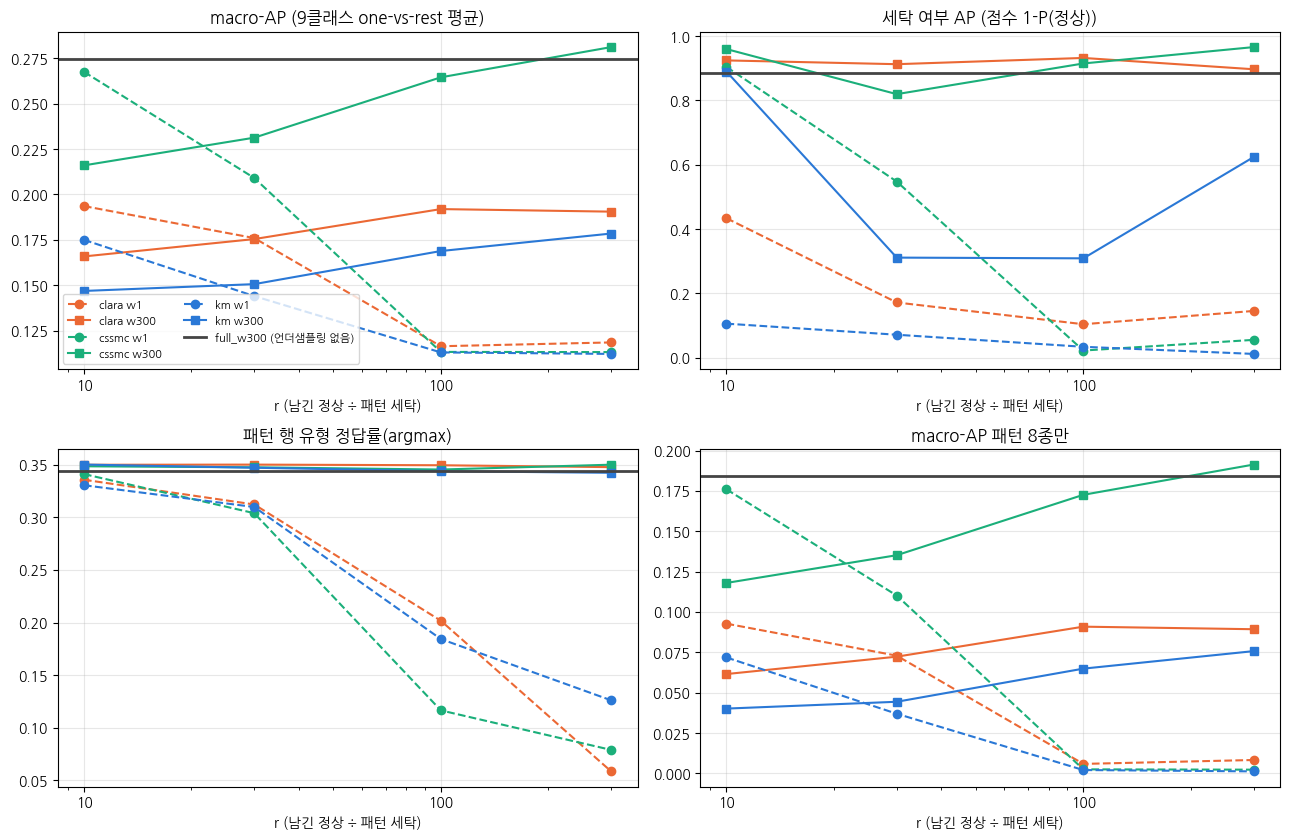

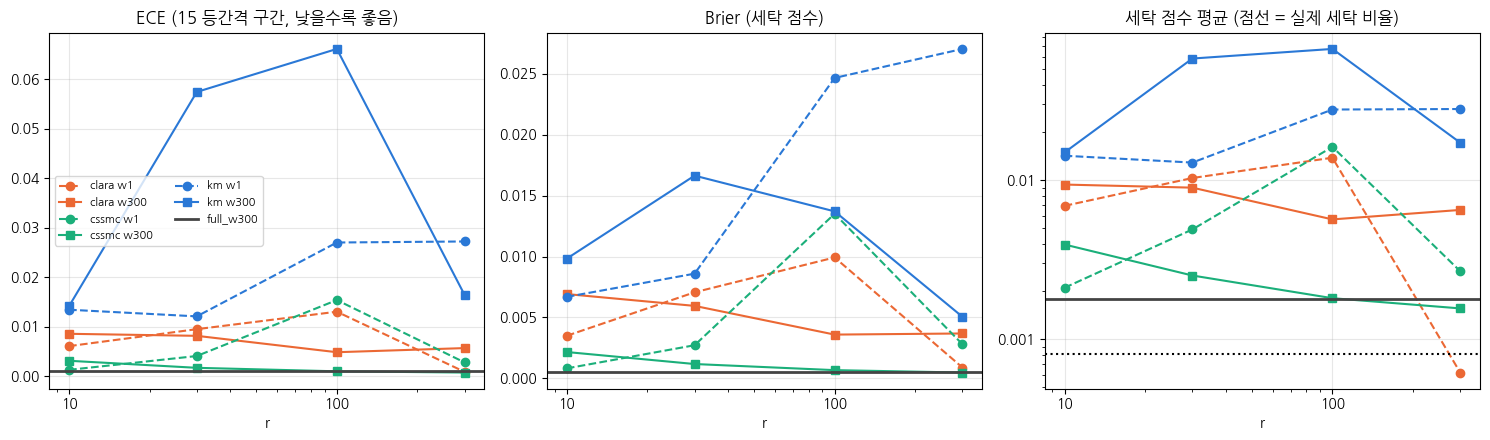

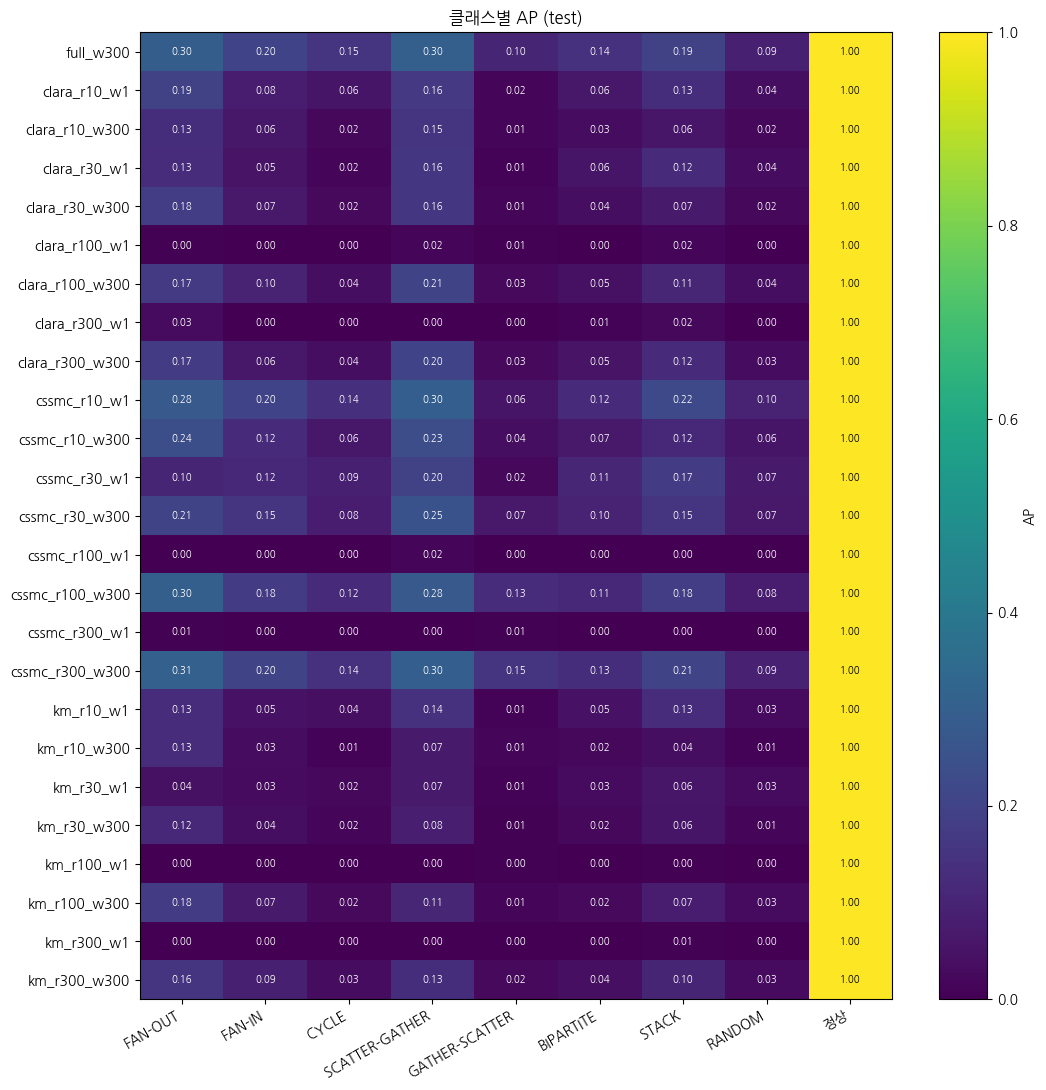

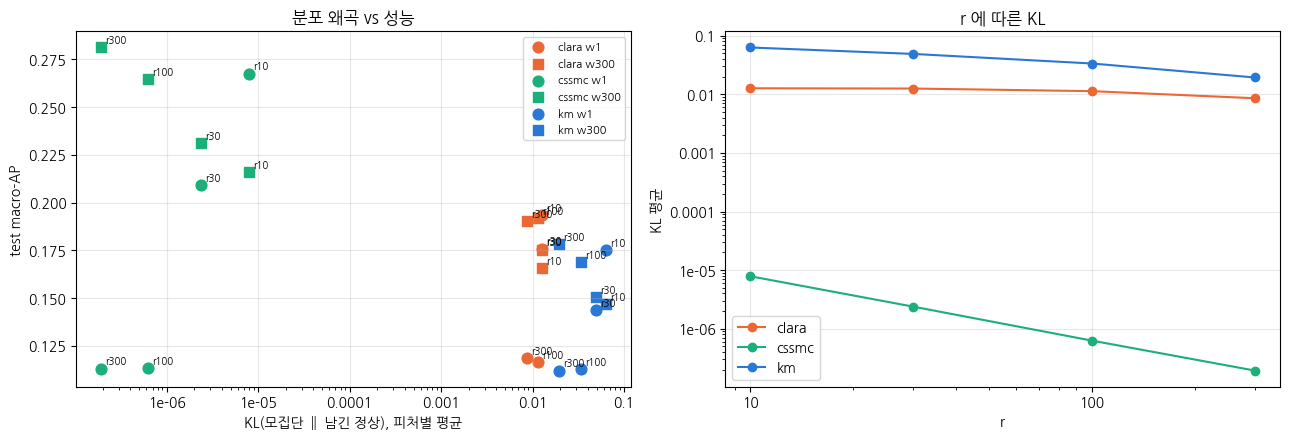

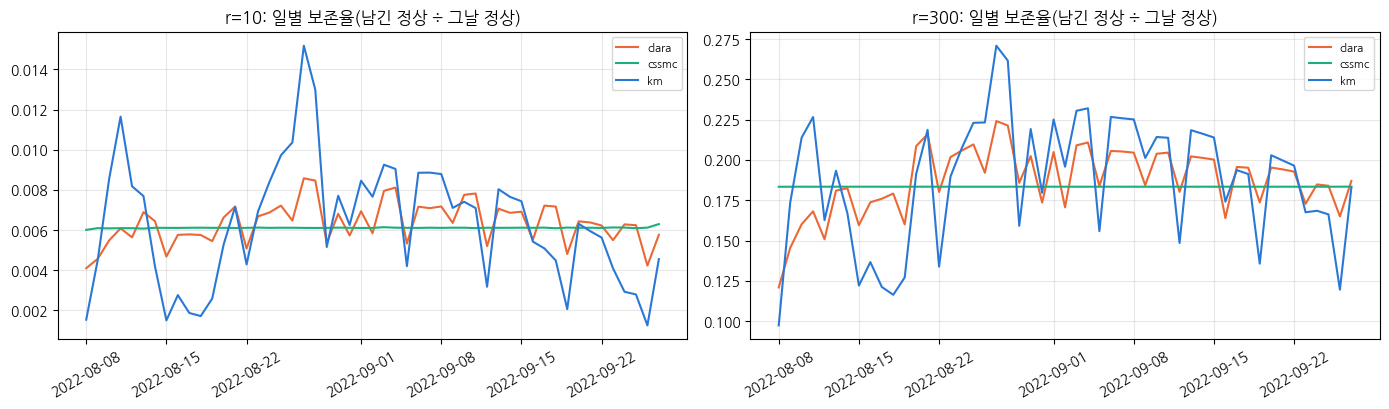

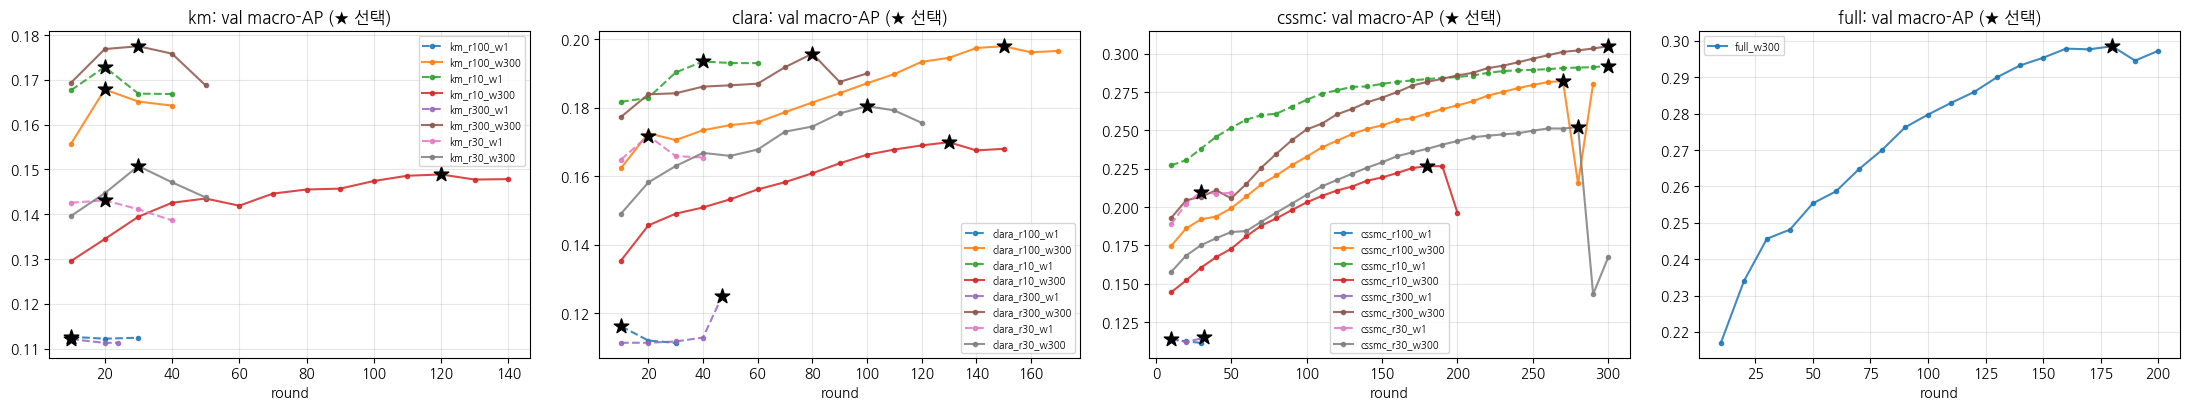

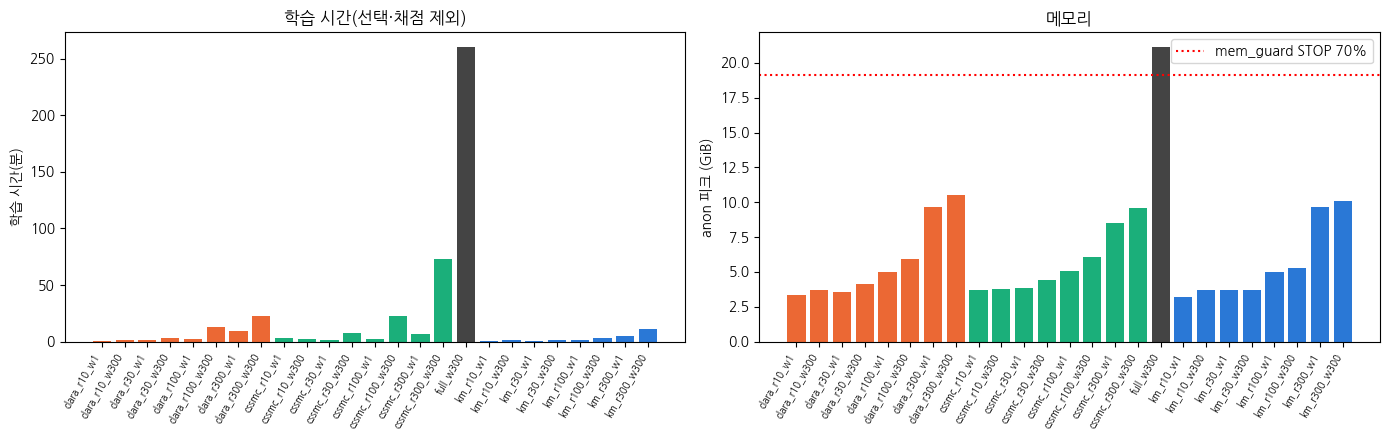

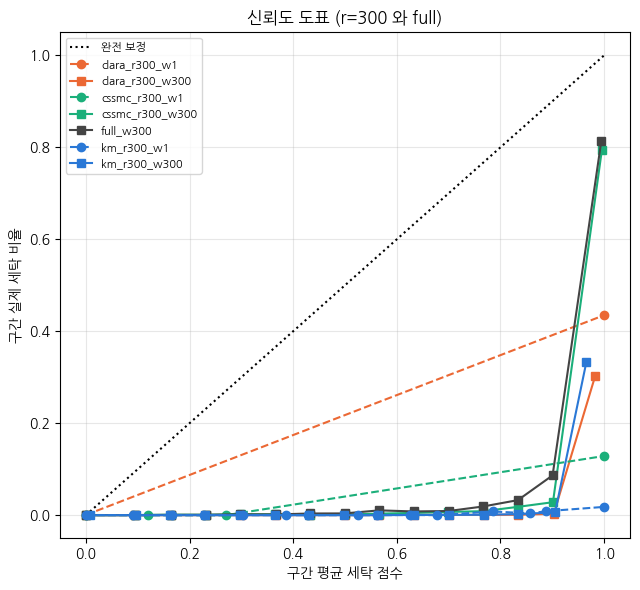

[05:21:40] 그림 8장 → /workspace/Final_preprocess/HI-Large_EDA/us_merged_20260928/_from_20260924/_figs · 9초


[05:21:40] figs 끝 · anon 2.3 GiB


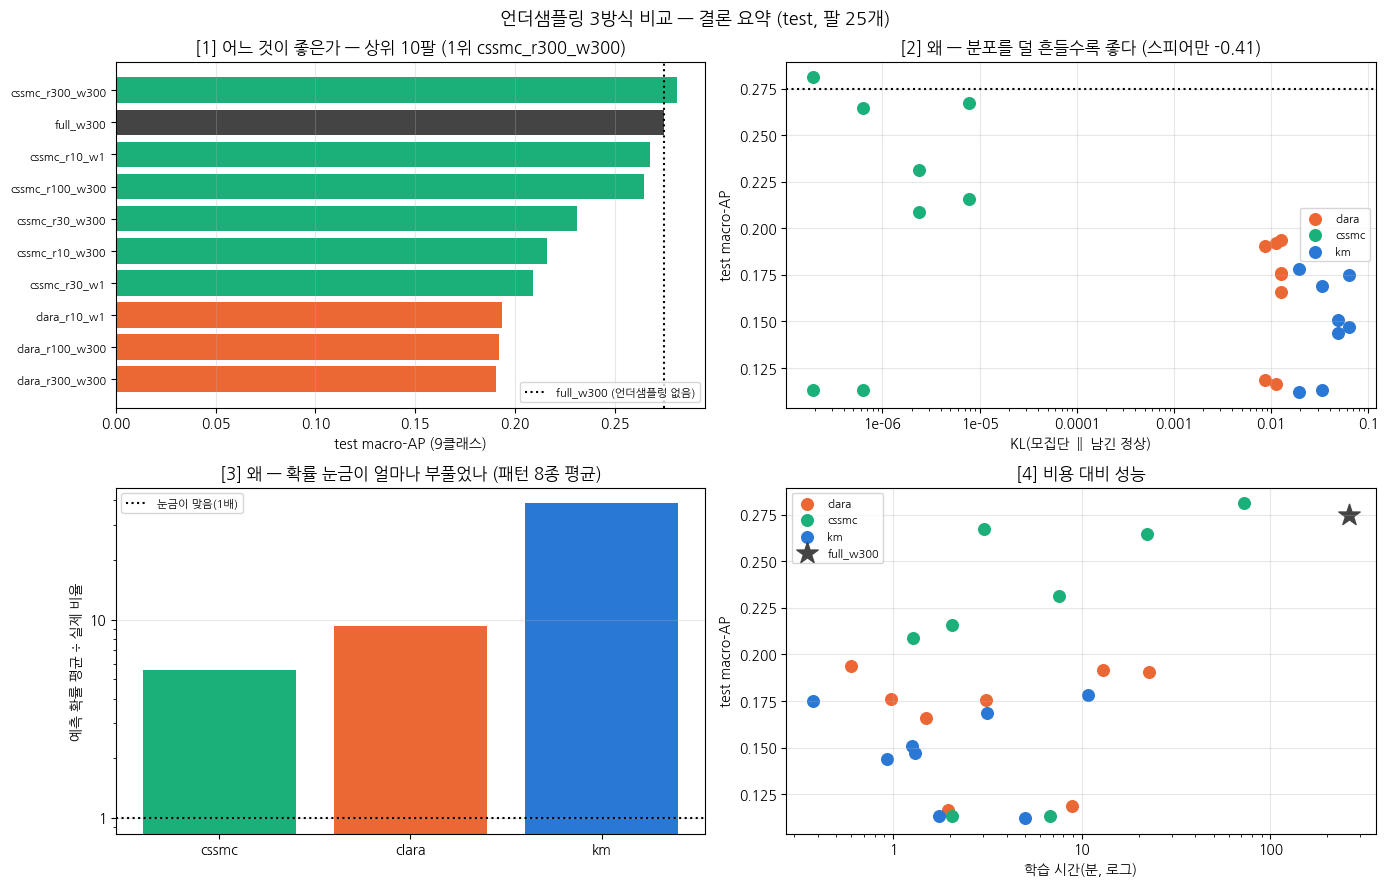


══════════════════════════════════════════════════════════════════════════════
  결론 — 어느 언더샘플링이 어떤 점에서 왜 좋은가   (팔 25개 · 상태 제안·미결)
══════════════════════════════════════════════════════════════════════════════

[1] 어느 것이 제일 좋은가
    1위 cssmc_r300_w300 · test macro-AP 0.28117 (val 0.30490)
    2위 full_w300 · 0.27479 · 차이 +0.00638
    언더샘플링 없음(full_w300) 대비 +0.00638 (+2.32%) · 학습 행 16,806,937 vs 91,383,419 (18.4%) · 학습 시간 73분 vs 260분 · anon 피크 9.6 vs 21.1 GiB

[2] 어떤 점에서
            지표      방향            최고_팔    최고_값   선두팔_값  선두팔이_최고
    macro_AP_9 높을수록 좋음 cssmc_r300_w300 0.28117 0.28117     True
 macro_AP_패턴8종 높을수록 좋음 cssmc_r300_w300 0.19132 0.19132     True
       세탁여부_AP 높을수록 좋음 cssmc_r300_w300 0.96567 0.96567     True
         AP_정상 높을수록 좋음 cssmc_r300_w300 1.00000 1.00000     True
    패턴행중_유형정답률 높을수록 좋음     km_r10_w300 0.35037 0.35024    False
세탁여부_argmax_F1 높을수록 좋음 cssmc_r300_w300 0.77737 0.77737     True
   ECE_세탁_15구간 낮을수록 좋음 cssmc_r300_w300 0.00076 0.00076     True
      Brier_세탁 

[05:21:43] verdict 끝 · anon 2.2 GiB


[05:21:43] DONE_POST


In [17]:
# ══════════════════════════════════════════════════════════════════════
# §14 실행
# ══════════════════════════════════════════════════════════════════════
FN = dict(stats=stage_stats, kmeans=stage_kmeans, clara=stage_clara, select=stage_select, subsets=stage_subsets, report=stage_report,
          raw=stage_raw, train=stage_train, analyze=stage_analyze, figs=stage_figs, verdict=stage_verdict)
# 09-22·23 실측(HI-Large 전량, 4코어). 시간을 가늠하는 용도이지 보장값이 아니다.
ETA = dict(stats='4분', kmeans='19분', clara='48분(제일 느림 · --methods 로 뺄 수 있다)', select='8분', subsets='8분',
           report='수 초', raw='수십 분(/tmp 에 이미 있으면 건너뜀)',
           train='언더샘플 24팔 합 18시간(팔당 중앙값 24분) + full_w300 5.5시간', analyze='수 초', figs='20초', verdict='수 초')
# 출처: us_cmp_20260922/common/*_meta.json 의 sec · results/T11d_비용.csv (09-22~23 실측, 4코어). 보장값이 아니다.


def plan():
    want = list(GROUP[A.stage]) if A.stage in GROUP else [A.stage]
    if 'clara' not in METHODS and 'clara' in want:
        want.remove('clara')
    return want


def child_args(stage, arms=None):
    c = [sys.executable, '-u', str(SELF), '--stage', stage, '--out', A.out, '--methods', ','.join(METHODS),
         '--ratios', ','.join(str(x) for x in CFG['ratios']), '--anon-stop', str(A.anon_stop), '--schema', A.schema]
    if A.big:
        c += ['--big', A.big]
    if A.source:
        c += ['--source', A.source]
    if arms:
        c += ['--arms', ','.join(arms)]
    if A.resume:
        c += ['--resume']
    if SMOKE:
        c += ['--smoke']
    return c


def main():
    install_sigterm()
    want = plan()
    log(f'{SELF.name} · {"스모크" if SMOKE else "전량"} · 방식 {",".join(METHODS)} · r {list(CFG["ratios"])} · '
        f'단계 {",".join(want)} · out {ROOT} · big {BIG} · anon 한도 {A.anon_stop} GiB')
    log(f'스키마 {SCHEMA} (sha1 {sha1(SCHEMA)}) → 54열')
    if DROPPED:
        log(f'!! 스키마에 있으나 결합 파일(62열)에 없어 뺀 열 {len(DROPPED)}개: {DROPPED}')
    if A.source:
        log(f'post 단계는 팔을 {SRC_ARMS} 에서 읽는다')
    if A.dry_run:
        for st in want:
            mark = '건너뜀(이미 끝남)' if stage_done(st) else '실행'
            if st == 'train':
                left = [a for a in ARM_RUN if not (ARMS / a / 'run.json').exists()]
                mark = f'실행 — 남은 팔 {len(left)}/{len(ARM_RUN)}' if left else '건너뜀(팔 전부 끝남)'
            log(f'  {st:8s} {mark:28s} 예상 {ETA[st]}')
        return 0
    if A.isolate and not SELF.exists():
        log(f'!! --isolate 인데 {SELF} 가 없다 → 한 프로세스로 돌린다(--no-isolate 와 같음)'); A.isolate = False
    if A.stage in GROUP and A.isolate:
        # 단계마다(학습은 팔마다) 별도 프로세스 — 앞 단계 메모리를 완전히 반납한다(기존 us_chainA/B/C 와 같은 거동)
        for st in want:
            if st == 'train':
                left = [a for a in ARM_RUN if not (ARMS / a / 'run.json').exists()]
                if not left:
                    log('train 건너뜀 (팔 전부 끝남)'); continue
                for j, arm in enumerate(left, 1):
                    log(f'▶ [{j}/{len(left)}] train {arm}')
                    rc = subprocess.call(child_args('train', [arm]))
                    if rc != 0:
                        status(f'STOP train {arm} rc={rc}'); log(f'STOP train {arm} rc={rc}'); return 1
                continue
            if stage_done(st):
                log(f'{st} 건너뜀 (이미 끝남 — 다시 하려면 {STAGED / (st + ".json")} 삭제)'); continue
            log('▶ ' + ' '.join(child_args(st)))
            rc = subprocess.call(child_args(st))
            if rc != 0:
                status(f'STOP {st} rc={rc}'); log(f'STOP {st} rc={rc}'); return 1
        status(f'DONE_{A.stage.upper()}'); log(f'DONE_{A.stage.upper()}'); return 0
    for st in want:
        if st != 'train' and stage_done(st):
            log(f'{st} 건너뜀 (이미 끝남 — 다시 하려면 {STAGED / (st + ".json")} 삭제)'); continue
        FN[st](); gc.collect()                        # 한 프로세스로 돌 때 단계 사이에 메모리를 돌려준다
        log(f'{st} 끝 · anon {L.anon_gib():.1f} GiB')
    if A.stage in GROUP:
        status(f'DONE_{A.stage.upper()}'); log(f'DONE_{A.stage.upper()}')
    return 0


if __name__ == '__main__':
    if _NB and not globals().get('RUN', False):
        print('RUN = False — 실행하지 않았다(보관용 기본값). 첫 셀에서 RUN = True 로 바꾸면 돈다.')
    elif _NB:
        main()
    else:
        sys.exit(main())